**Análise de Sucesso e Inserção no Mercado: Estudantes do CI-UFPB vs. Mercado de Trabalho
Integrantes: Ítalo Mendonça, Julia Rosa, Maria Nathalia.**

**Motivação:** 

A área de tecnologia é historicamente marcada por uma baixa representatividade feminina.Esta análise surge da necessidade de quantificar se o desempenho acadêmico das estudantes se reflete em uma inserção equivalente no mercado de trabalho ou se existem barreiras de gênero após a saída da universidade.


**Objetivos:**

Comparar a proporção de gênero entre as atividades internas do CI (Monitoria, PIBIC, PROBEX) e as convocações externas do Diário Oficial.


Identificar se a taxa de "sucesso" (aprovação em estágios e residências) varia significativamente entre homens e mulheres.


Propor, através de análise de dados, uma visão sobre o impacto dos projetos de extensão na carreira das mulheres.


**Fontes de Dados e Coleta**


Neste projeto, utilizamos duas fontes principais de dados para permitir a comparação entre o ambiente acadêmico (interno) e o mercado de trabalho (externo):

Dados Externos (Diário Oficial da União - DOU): * Origem: Nomeações para cargos públicos federais extraídas do DOU entre os anos de 2019 e 2025.

O CSV é separado por data, nome e gênero, exemplo: 


15-01-2019,ÉMERSON GUIMARÃES DAL SECCHI,Masculino


28-01-2019,FABIANA COSTA OLIVEIRA BARRETO,Feminino


31-01-2019,ANA CRISTINA LIMA BARREIROS DA SILVA,Feminino


Volume Inicial: Aproximadamente 5921 registros.


Atributos: Data (da publicação), Nome (do nomeado) e Gênero (identificado via algoritmo de processamento de linguagem natural ou base de nomes).




Dados Internos (UFPB - Centro de Informática):

Origem: Relatórios de editais internos para Monitoria, Iniciação Científica (PIBIC) e Extensão (PROBEX).

Escopo: Discentes matriculados em cursos do CI-UFPB.

Significância: Estes dados servem como base para entender o "funil" de gênero antes da saída para o mercado.




**Pré-processamento e Tratamento de Dados**


Para garantir a integridade da análise e a confiabilidade dos modelos estatísticos, os dados brutos extraídos do Diário Oficial da União (DOU) passaram por um fluxo de tratamento rigoroso (pipeline), dividido em quatro fases principais:

1. Diagnóstico de Qualidade e Integridade
Antes de qualquer alteração, foi realizada uma auditoria automatizada na base bruta para identificar:

Inconsistências Estruturais: Detecção de valores nulos, formatos de data inválidos e colunas com tipos de dados incorretos.

Análise de Ruído Textual: Identificação de nomes com capitalização mista, pontuação residual (pontos finais) e presença de caracteres especiais/apostrofos não padronizados.

Identificação de Títulos: Uso de expressões regulares (Regex) para localizar prefixos militares e profissionais que precediam os nomes, o que poderia enviesar a identificação de gênero e a contagem de indivíduos únicos.

2. Padronização e Normalização Textual
Nesta fase, o objetivo foi eliminar variações ortográficas que fariam o algoritmo interpretar a mesma pessoa como indivíduos diferentes:

Normalização Unicode (NFC): Aplicamos a normalização NFC (Canonical Decomposition followed by Canonical Composition) para garantir que caracteres acentuados tivessem uma representação binária única. Isso evita erros comuns em bancos de dados onde, por exemplo, o "ã" pode ser representado de duas formas diferentes.

Standardization de Caixa: Todos os nomes foram convertidos para MAIÚSCULAS e submetidos à função strip() para remoção de espaços em branco sobressalentes no início e fim das strings.

Saneamento de Caracteres: Normalização de apóstrofos e remoção de pontos finais residuais ao final dos nomes.

3. Limpeza de Atributos e Remoção de Títulos (Noise Removal)
Para isolar o nome próprio (essencial para a análise de gênero), implementamos uma limpeza baseada em padrões:

Filtragem de Prefixos: Utilizou-se um motor de Regex para identificar e remover patentes militares (ex: Ten., Cel., Maj., Sgt.) e títulos acadêmicos/profissionais. Sem essa limpeza, o primeiro nome seria identificado erroneamente como o título, e não como o prenome, invalidando a classificação de gênero.

4. Deduplicação e Estruturação Temporal
Com os dados limpos, procedeu-se à consolidação da base:

Deduplicação Inteligente: Registros duplicados (mesmo nome, mesma data e mesmo gênero) foram eliminados. Isso garante que a análise reflita o volume de pessoas nomeadas e não o número de linhas ou republicações no Diário Oficial.

Conversão de Tipagem: A coluna de datas foi convertida para o tipo datetime64[ns], permitindo a agregação por séries temporais (ano e mês), requisito fundamental para a aplicação do modelo de Regressão Linear que projeta a participação feminina.



Tratamento de Ambiguidades e Nomes Compostos:
Para garantir a precisão da classificação, os nomes compostos foram mantidos integralmente durante a normalização, evitando perdas de distinção entre indivíduos. A identificação de gênero foi realizada por meio de consultas à API de nomes do IBGE (Instituto Brasileiro de Geografia e Estatística), que utiliza a frequência estatística de registros civis no Brasil para atribuir o gênero ao prenome com base na base de dados do Censo, conferindo maior confiabilidade metodológica e fundamentação estatística oficial ao processo de rotulagem.

In [21]:
#Pré-Processamento

"""
Limpeza de Dados - Nomeacoes por Genero (Diario Oficial da Uniao)
==================================================================
Responsabilidade unica: diagnosticar, limpar e salvar o CSV tratado.
Para analises e graficos, use: analise_nomeacoes.py

Problemas corrigidos:
  1. 3.023 linhas duplicadas (mesmo Nome + Data repetidos 2x)
  2. 244 nomes com capitalizacao mista
  3.   5 nomes com ponto final
  4.   5 nomes com prefixo militar
  5.   4 nomes com apostrofos especiais

Uso:
    python limpeza_dados.py
    python limpeza_dados.py --entrada meu_arquivo.csv --saida dados_limpos.csv

Requisitos:
    pip install pandas
"""

import sys
import argparse
import unicodedata
import pandas as pd

# Forca UTF-8 no terminal (necessario no Windows com cp1252)
#sys.stdout = open(sys.stdout.fileno(), mode="w", encoding="utf-8", buffering=1)

ARQUIVO_ENTRADA = "historico_nomeacoes_longo_prazo.csv"
ARQUIVO_SAIDA   = "nomeacoes_limpo.csv"


# =============================================================================
# 1. DIAGNOSTICO - resume os problemas encontrados antes de qualquer alteracao
# =============================================================================
def diagnosticar(df):
    sep = "-" * 55
    print(sep)
    print("DIAGNOSTICO DE QUALIDADE")
    print(sep)
    print(f"Linhas totais             : {len(df):>6,}")
    print(f"Colunas                   : {list(df.columns)}")
    print()

    print("-- Valores nulos por coluna --")
    nulos = df.isnull().sum()
    for col, n in nulos.items():
        status = "OK" if n == 0 else f"ATENCAO: {n}"
        print(f"  {col:<10}: {status}")
    print()

    n_dup = df.duplicated().sum()
    flag = "CRITICO" if n_dup > 0 else "OK"
    print(f"Duplicatas exatas         : {n_dup:>6,}  [{flag}]")

    n_misto = (~df["Nome"].str.isupper() & ~df["Nome"].str.islower()).sum()
    print(f"Nomes capitalizacao mista : {n_misto:>6,}  [{'ATENCAO' if n_misto else 'OK'}]")

    n_ponto = df["Nome"].str.strip().str.endswith(".").sum()
    print(f"Nomes com ponto final     : {n_ponto:>6,}  [{'ATENCAO' if n_ponto else 'OK'}]")

    prefixos = r"^(Gen|Gal|Cel|Cor|Maj|Cap|Ten|Sgt|Cb|Sd)\b"
    n_pref = df["Nome"].str.contains(prefixos, case=False, regex=True).sum()
    print(f"Nomes com prefixo militar : {n_pref:>6,}  [{'ATENCAO' if n_pref else 'OK'}]")

    n_apo = df["Nome"].str.contains(r"[`\xb4]", regex=True).sum()
    print(f"Nomes com apostrofo esp.  : {n_apo:>6,}  [{'ATENCAO' if n_apo else 'OK'}]")

    data_invalida = pd.to_datetime(df["Data"], format="%d-%m-%Y", errors="coerce").isna().sum()
    print(f"Datas invalidas           : {data_invalida:>6,}  [{'CRITICO' if data_invalida else 'OK'}]")

    print()
    print("-- Categorias em Genero --")
    for val, cnt in df["Genero"].value_counts(dropna=False).items():
        print(f"  {val:<12}: {cnt:,}")

    print(sep)


# =============================================================================
# 2. LIMPEZA
# =============================================================================
def limpar(df):
    df = df.copy()
    log = []

    # 2.1 Strip em todos os campos de texto
    for col in ["Nome", "Genero", "Data"]:
        df[col] = df[col].str.strip()
    log.append("Espacos extras removidos (strip).")

    # 2.2 Normalizacao Unicode NFC
    for col in ["Nome", "Genero"]:
        df[col] = df[col].apply(
            lambda x: unicodedata.normalize("NFC", x) if isinstance(x, str) else x
        )
    log.append("Normalizacao Unicode NFC aplicada.")

    # 2.3 Remover ponto final dos nomes
    n = df["Nome"].str.endswith(".").sum()
    df["Nome"] = df["Nome"].str.rstrip(".")
    log.append(f"Ponto final removido de {n} nomes.")

    # 2.4 Remover prefixos militares
    prefixos = r"^(Gen\s+Div|Gen|Gal|Cel|Cor|Maj|Cap|Ten|Sgt|Cb|Sd)\s+"
    n = df["Nome"].str.contains(prefixos, case=False, regex=True).sum()
    df["Nome"] = df["Nome"].str.replace(prefixos, "", case=False, regex=True)
    log.append(f"Prefixos militares removidos de {n} nomes.")

    # 2.5 Normalizar apostrofos especiais (` e acento agudo) para '
    n = df["Nome"].str.contains(r"[`\xb4]", regex=True).sum()
    df["Nome"] = df["Nome"].str.replace(r"[`\xb4]", "'", regex=True)
    log.append(f"Apostrofos especiais normalizados em {n} nomes.")

    # 2.6 Padronizar nomes para MAIUSCULAS
    n = (~df["Nome"].str.isupper() & ~df["Nome"].str.islower()).sum()
    df["Nome"] = df["Nome"].str.upper()
    log.append(f"Nomes padronizados para maiusculas ({n} tinham capitalizacao mista).")

    # 2.7 Remover duplicatas (feito APOS normalizacao para capturar
    #     duplicatas que diferiam apenas em capitalizacao ou pontuacao)
    n_antes = len(df)
    df = df.drop_duplicates(subset=["Nome", "Data", "Genero"]).reset_index(drop=True)
    n_removidas = n_antes - len(df)
    log.append(f"Duplicatas removidas: {n_removidas:,} linhas ({n_antes:,} -> {len(df):,}).")

    # 2.8 Converter Data para datetime e reordenar por data
    df["Data"] = pd.to_datetime(df["Data"], format="%d-%m-%Y")
    df = df.sort_values("Data").reset_index(drop=True)
    log.append("Coluna Data convertida para datetime e registros ordenados por data.")

    print("\n-- LOG DE LIMPEZA --")
    for i, msg in enumerate(log, 1):
        print(f"  {i}. {msg}")
    print(f"\n  Resultado final: {len(df):,} linhas | {df.shape[1]} colunas.")

    return df


# =============================================================================
# 3. SALVAR
# =============================================================================
def salvar(df, caminho):
    # Salva a data de volta para o formato original dd-mm-yyyy
    df_out = df.copy()
    df_out["Data"] = df_out["Data"].dt.strftime("%d-%m-%Y")
    df_out.to_csv(caminho, index=False, encoding="utf-8-sig")
    print(f"\nCSV limpo salvo em: {caminho}")
    print(f"  Encoding : utf-8-sig (compativel com Excel)")
    print(f"  Linhas   : {len(df_out):,}")
    print(f"  Colunas  : {list(df_out.columns)}")


# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="Limpa o CSV de nomeacoes e salva uma versao tratada."
    )
    parser.add_argument(
        "--entrada", default=ARQUIVO_ENTRADA,
        help=f"CSV de entrada (padrao: {ARQUIVO_ENTRADA})"
    )
    parser.add_argument(
        "--saida", default=ARQUIVO_SAIDA,
        help=f"CSV de saida (padrao: {ARQUIVO_SAIDA})"
    )
    args = parser.parse_args(args=[])

    print(f"Carregando: {args.entrada}")
    df_raw = pd.read_csv(args.entrada)

    diagnosticar(df_raw)
    df_limpo = limpar(df_raw)
    salvar(df_limpo, args.saida)

    print("\nLimpeza concluida. Use analise_nomeacoes.py para os graficos e regressao.")

Carregando: historico_nomeacoes_longo_prazo.csv
-------------------------------------------------------
DIAGNOSTICO DE QUALIDADE
-------------------------------------------------------
Linhas totais             :  5,921
Colunas                   : ['Data', 'Nome', 'Genero']

-- Valores nulos por coluna --
  Data      : OK
  Nome      : OK
  Genero    : OK

Duplicatas exatas         :  3,023  [CRITICO]
Nomes capitalizacao mista :    244  [ATENCAO]
Nomes com ponto final     :      5  [ATENCAO]
Nomes com prefixo militar :      5  [ATENCAO]
Nomes com apostrofo esp.  :      4  [ATENCAO]
Datas invalidas           :      0  [OK]

-- Categorias em Genero --
  Feminino    : 3,263
  Masculino   : 2,658
-------------------------------------------------------

-- LOG DE LIMPEZA --
  1. Espacos extras removidos (strip).
  2. Normalizacao Unicode NFC aplicada.
  3. Ponto final removido de 5 nomes.
  4. Prefixos militares removidos de 5 nomes.
  5. Apostrofos especiais normalizados em 4 nomes.
  6. N

C:\Users\redca\AppData\Local\Temp\ipykernel_4760\1504671210.py:66: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n_pref = df["Nome"].str.contains(prefixos, case=False, regex=True).sum()
C:\Users\redca\AppData\Local\Temp\ipykernel_4760\1504671210.py:109: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  n = df["Nome"].str.contains(prefixos, case=False, regex=True).sum()


Após a limpeza, dados duplicados e sujos foram retirados

### Perguntas

**1. A presença feminina nas convocações do mercado de trabalho apresentou crescimento real entre os anos de 2020 e 2025?**
**2. Qual a previsão da participação feminina no mercado público pelos próximos anos?**

In [22]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.linear_model import LinearRegression

# Configuração visual dos gráficos
CORES = {"Feminino": "#1D9E75", "Masculino": "#7F77DD", "previsao": "#EF9F27"}
plt.rcParams.update({
    "font.family": "DejaVu Sans", 
    "axes.spines.top": False,
    "axes.spines.right": False, 
    "figure.dpi": 130
})

#### Carregamento dos Dados e Resumo Anual
Primeiro, vamos carregar os dados limpos do Diário Oficial, filtrando até o ano de 2025 para garantir anos completos, e gerar uma tabela com o percentual de participação por gênero a cada ano.

In [23]:
def carregar_dados(caminho: str) -> pd.DataFrame:
    df = pd.read_csv(caminho)
    df["Data"] = pd.to_datetime(df["Data"], format="%d-%m-%Y")
    df["Ano"] = df["Data"].dt.year
    df["Mes"] = df["Data"].dt.month
    # remove 2026 (dados parciais)
    df = df[df["Ano"] < 2026].copy()
    return df

def resumo_anual(df: pd.DataFrame) -> pd.DataFrame:
    tabela = (
        df.groupby(["Ano", "Genero"])
        .size()
        .unstack(fill_value=0)
        .rename(columns={"Feminino": "Feminino", "Masculino": "Masculino"})
    )
    tabela["Total"]    = tabela["Feminino"] + tabela["Masculino"]
    tabela["% Feminino"] = (tabela["Feminino"] / tabela["Total"] * 100).round(1)
    tabela["% Masculino"] = (tabela["Masculino"] / tabela["Total"] * 100).round(1)
    return tabela

# Execução
ARQUIVO = "nomeacoes_limpo.csv" # Certifique-se que o arquivo está na mesma pasta
df = carregar_dados(ARQUIVO)
tabela_resumo = resumo_anual(df)
tabela_resumo

Genero,Feminino,Masculino,Total,% Feminino,% Masculino
Ano,,,,,
2019,94,62,156,60.3,39.7
2020,40,21,61,65.6,34.4
2021,15,18,33,45.5,54.5
2022,355,392,747,47.5,52.5
2023,120,148,268,44.8,55.2
2024,314,266,580,54.1,45.9
2025,632,411,1043,60.6,39.4


#### Visualização Histórica (2020 - 2025)
Com os dados consolidados, podemos observar o volume absoluto de nomeações e a proporção feminina em relação à linha de paridade (50%).

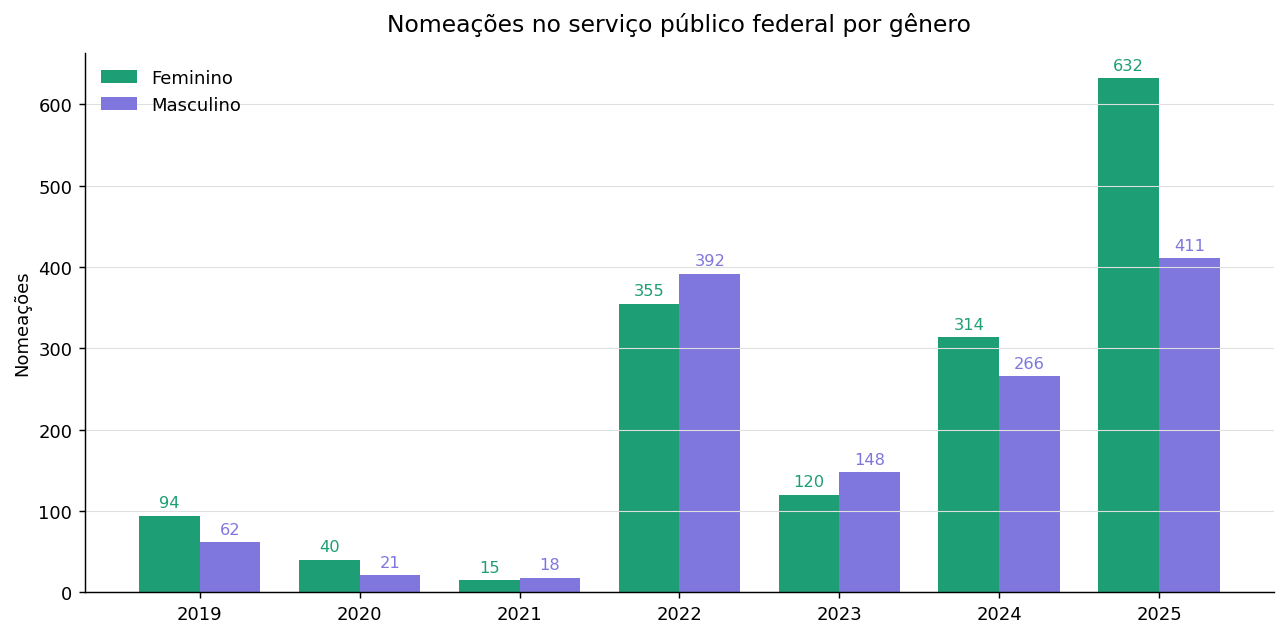

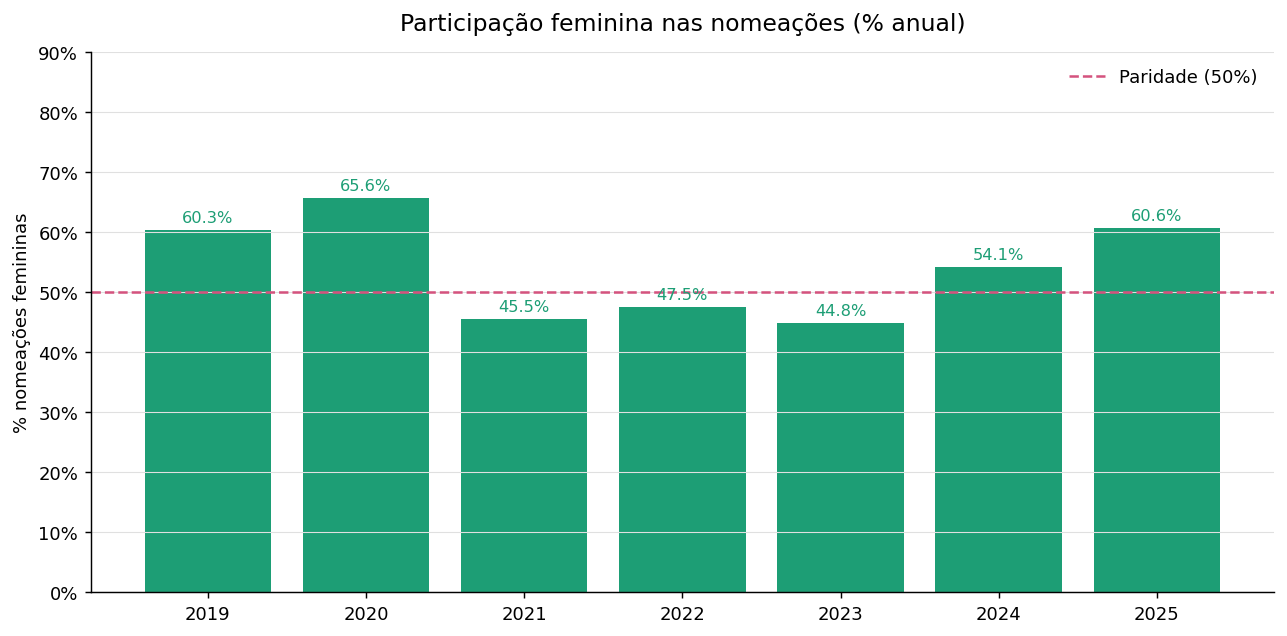

In [24]:
def plot_volume_anual(tabela: pd.DataFrame):
    anos  = tabela.index.astype(str)
    x     = np.arange(len(anos))
    width = 0.38

    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - width/2, tabela["Feminino"],  width, label="Feminino", color=CORES["Feminino"], linewidth=0)
    b2 = ax.bar(x + width/2, tabela["Masculino"], width, label="Masculino", color=CORES["Masculino"], linewidth=0)

    ax.bar_label(b1, padding=3, fontsize=9, color=CORES["Feminino"])
    ax.bar_label(b2, padding=3, fontsize=9, color=CORES["Masculino"])

    ax.set_xticks(x)
    ax.set_xticklabels(anos)
    ax.set_ylabel("Nomeações")
    ax.set_title("Nomeações no serviço público federal por gênero", fontsize=13, pad=12)
    ax.legend(frameon=False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", ".")))
    ax.grid(axis="y", color="#e0e0e0", linewidth=0.6)
    plt.tight_layout()
    plt.show()

def plot_participacao_feminina(tabela: pd.DataFrame):
    anos = tabela.index
    perc = tabela["% Feminino"]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(anos.astype(str), perc, color=CORES["Feminino"], linewidth=0)
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in perc], padding=3, fontsize=9, color=CORES["Feminino"])
    ax.axhline(50, color="#D4537E", linestyle="--", linewidth=1.4, label="Paridade (50%)")

    ax.set_ylim(0, 90)
    ax.set_ylabel("% nomeações femininas")
    ax.set_title("Participação feminina nas nomeações (% anual)", fontsize=13, pad=12)
    ax.legend(frameon=False)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis="y", color="#e0e0e0", linewidth=0.6)
    plt.tight_layout()
    plt.show()

# Execução dos gráficos
plot_volume_anual(tabela_resumo)
plot_participacao_feminina(tabela_resumo)

#### Regressão Linear e Previsão
Para responder à segunda parte da pergunta, aplicamos um modelo de Regressão Linear Simples (OLS) sobre a série histórica para projetar a tendência de participação feminina para os próximos 5 anos (2026 - 2030).

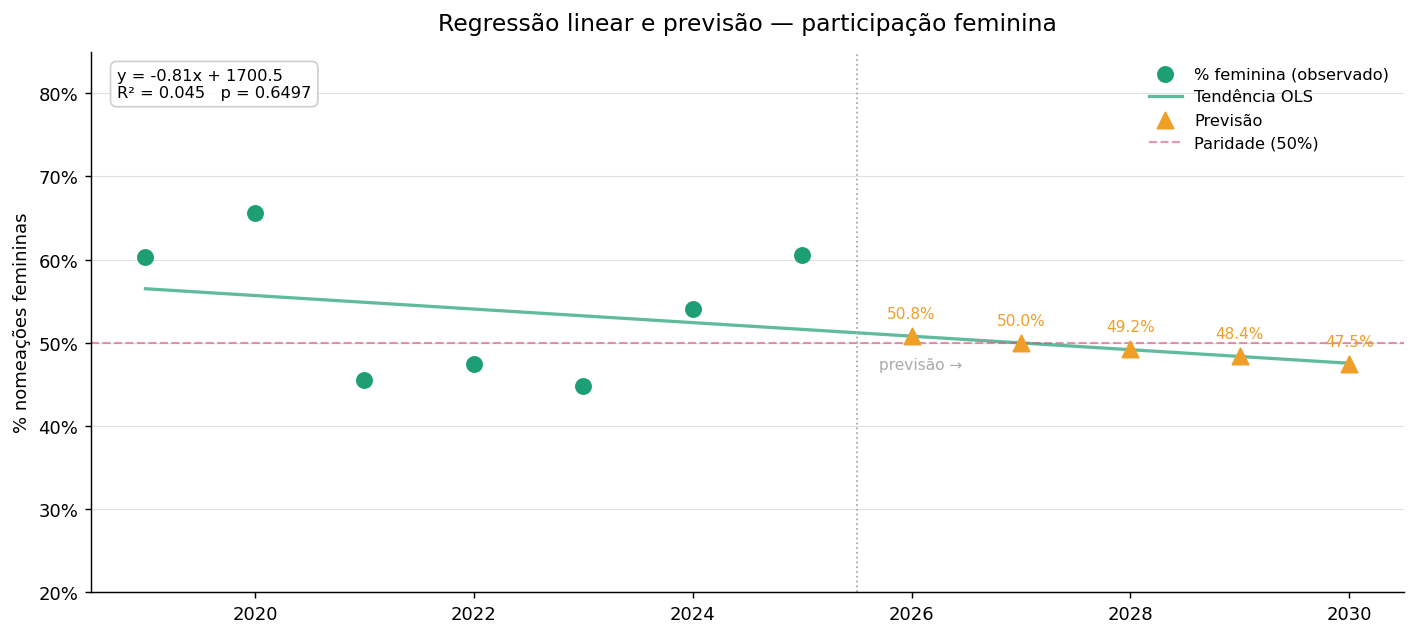

In [25]:
def regressao_e_previsao(tabela: pd.DataFrame, anos_previsao: list[int] = None):
    if anos_previsao is None:
        anos_previsao = list(range(2026, 2031))

    anos = tabela.index.values.reshape(-1, 1)
    perc = tabela["% Feminino"].values

    modelo = LinearRegression()
    modelo.fit(anos, perc)

    slope, intercept, r_val, p_val, std_err = stats.linregress(tabela.index.values, perc)

    resultado = {
        "coef_angular": slope,
        "intercepto": intercept,
        "R²": r_val**2,
        "p-valor": p_val,
        "erro_padrao": std_err,
    }

    todos_anos = np.array(anos_previsao).reshape(-1, 1)
    previsoes  = modelo.predict(todos_anos).clip(0, 100)
    df_prev = pd.DataFrame({"Ano": anos_previsao, "Previsão % Feminino": previsoes.round(1)})

    return resultado, df_prev

def plot_regressao(tabela: pd.DataFrame, resultado: dict, df_prev: pd.DataFrame):
    anos_hist = tabela.index.values
    perc_hist = tabela["% Feminino"].values

    todos_anos = np.arange(anos_hist.min(), df_prev["Ano"].max() + 1)
    tendencia  = resultado["coef_angular"] * todos_anos + resultado["intercepto"]

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.scatter(anos_hist, perc_hist, color=CORES["Feminino"], s=70, zorder=5, label="% feminina (observado)")
    ax.plot(todos_anos, tendencia, color=CORES["Feminino"], linewidth=1.8, alpha=0.7, label="Tendência OLS")
    ax.scatter(df_prev["Ano"], df_prev["Previsão % Feminino"], color=CORES["previsao"], s=80, zorder=5, marker="^", label="Previsão")

    for _, row in df_prev.iterrows():
        ax.annotate(f'{row["Previsão % Feminino"]:.1f}%',
                    xy=(row["Ano"], row["Previsão % Feminino"]),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=8.5, color=CORES["previsao"])

    ax.axhline(50, color="#D4537E", linestyle="--", linewidth=1.2, alpha=0.6, label="Paridade (50%)")
    ax.axvline(2025.5, color="#aaa", linestyle=":", linewidth=1)
    ax.text(2025.7, perc_hist.min() + 2, "previsão →", fontsize=8.5, color="#aaa")

    texto = (f"y = {resultado['coef_angular']:.2f}x "
             f"{'−' if resultado['intercepto'] < 0 else '+'} "
             f"{abs(resultado['intercepto']):.1f}\n"
             f"R² = {resultado['R²']:.3f}   "
             f"p = {resultado['p-valor']:.4f}")
    ax.text(0.02, 0.97, texto, transform=ax.transAxes, fontsize=9, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#ccc", alpha=0.9))

    ax.set_xlim(anos_hist.min() - 0.5, df_prev["Ano"].max() + 0.5)
    ax.set_ylim(20, 85)
    ax.set_ylabel("% nomeações femininas")
    ax.set_title("Regressão linear e previsão — participação feminina", fontsize=13, pad=12)
    ax.legend(frameon=False, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax.grid(axis="y", color="#e0e0e0", linewidth=0.6)
    plt.tight_layout()
    plt.show()

# Execução da Regressão
resultado, df_prev = regressao_e_previsao(tabela_resumo)
plot_regressao(tabela_resumo, resultado, df_prev)

Após a análise, verificou-se que as nomeações femininas no serviço público sofrem oscilções, mas permanecem próximas ao percentual de 50%

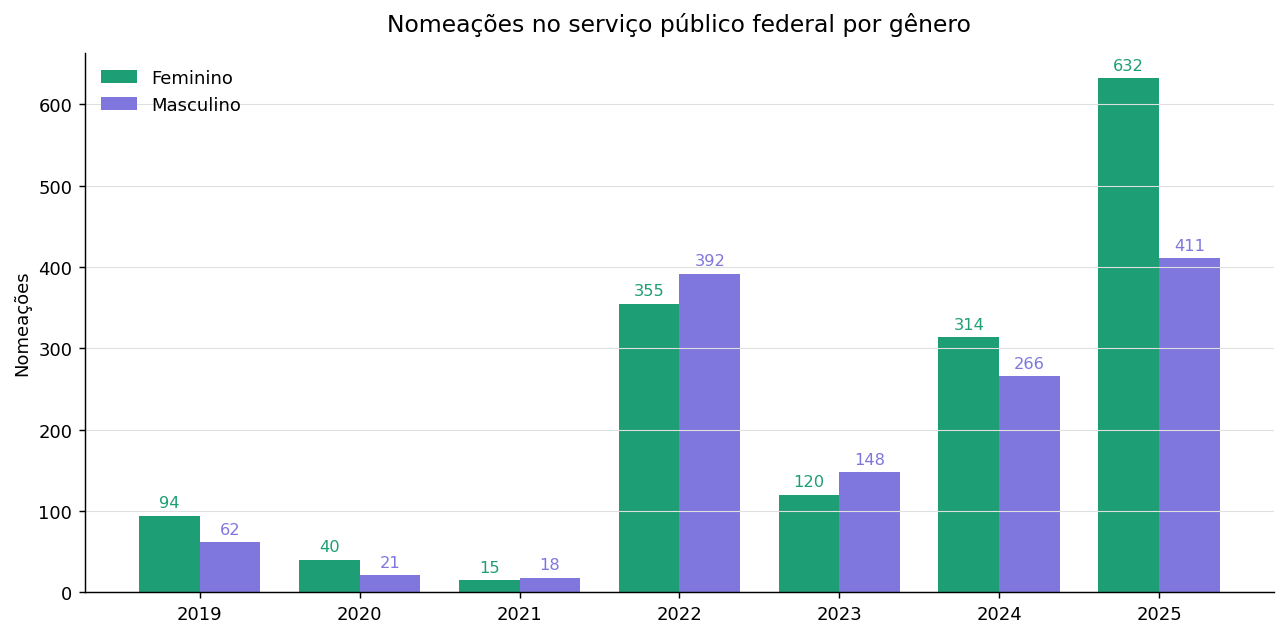

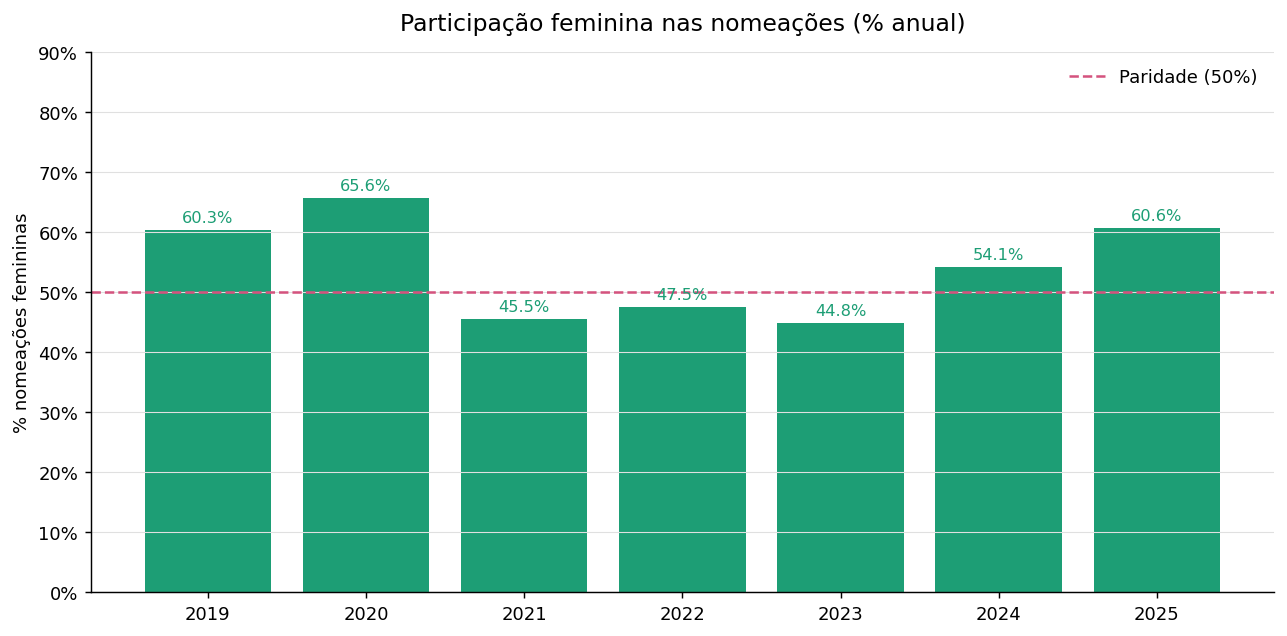

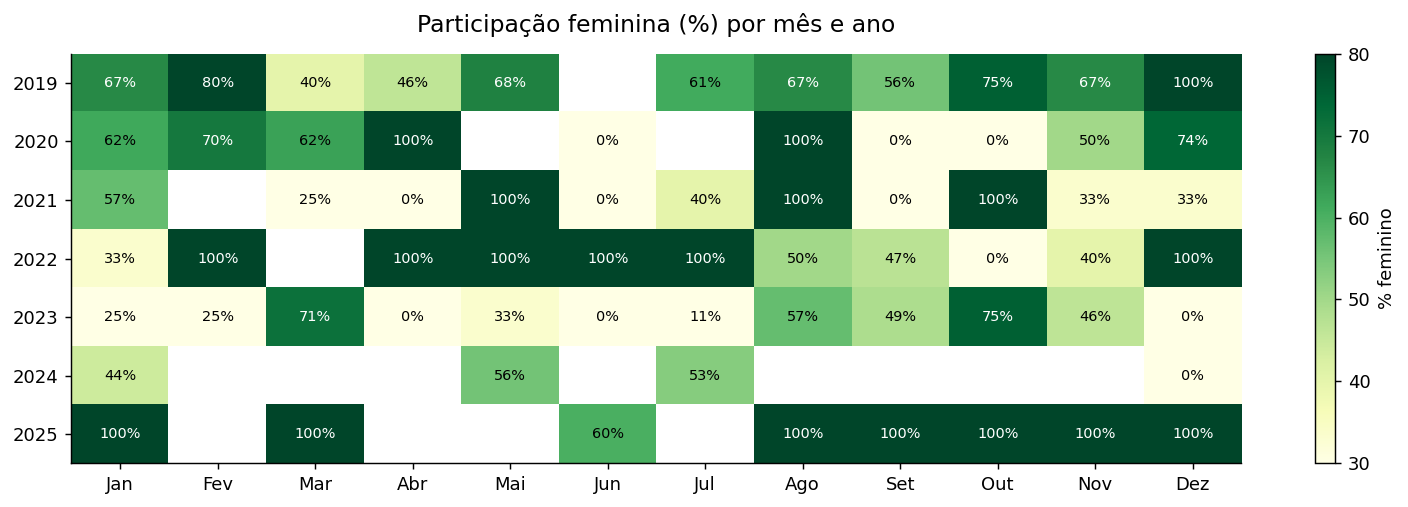

Após o cálculo de uma regressão linear, verificou-se uma reta decrescente, mas não necessariamente implicando na possibilidade da diminuição da participação feminina no serviço público nos próximos anos, pois os dados são muito voláteis e variados.

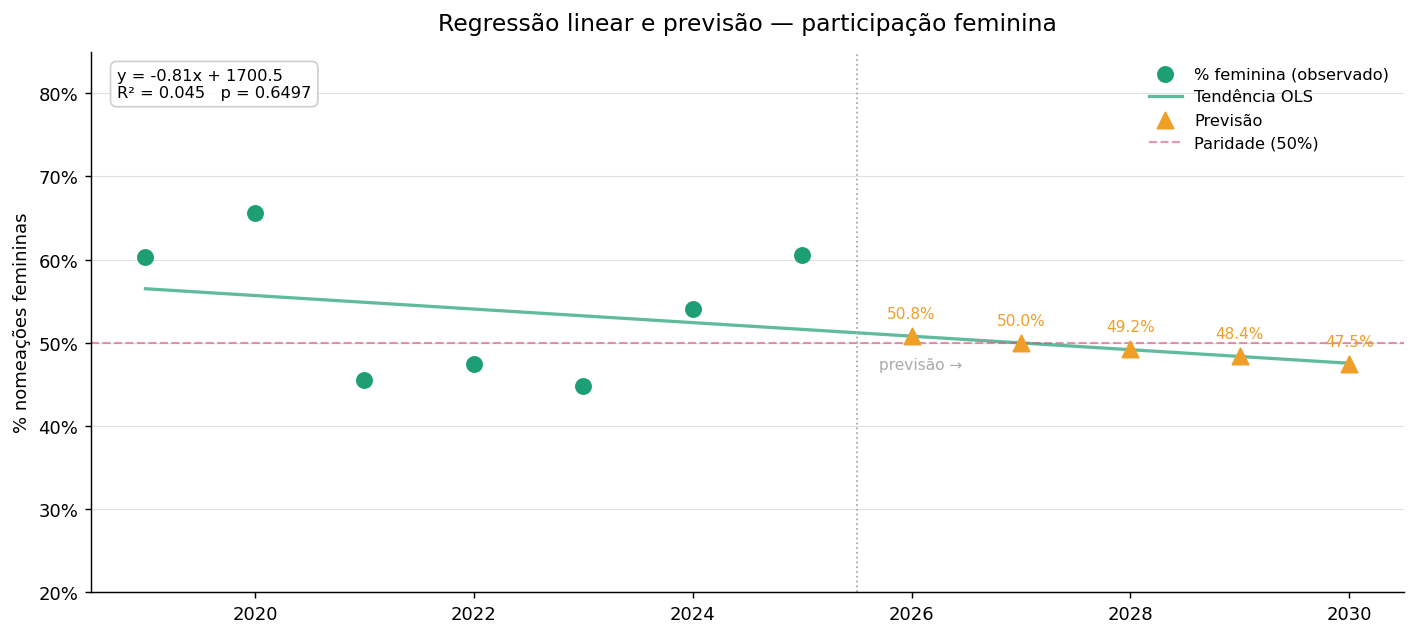

**2. O Funil de Gênero: Em qual modalidade do CI (Monitoria, Pesquisa ou Extensão) a participação feminina é maior e como isso se compara à sua presença em Estágios externos?**

**3. Paridade Acadêmica: Há paridade na participação feminina e masculina nos projetos da UFPB?**

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import unicodedata

ARQUIVO_EXCEL = "ufpb_planilha.xlsx"
PASTA_SAIDA = "graficos_gerados"

CURSOS = {
    "CDIA": "Ciência de Dados e Inteligência Artificial",
    "EC": "Engenharia da Computação",
    "CC": "Ciência da Computação"
}

PROGRAMAS = {
    "MONITORIA": "Monitoria",
    "PIBIC": "PIBIC",
    "PROBEX": "PROBEX",
    "ESTAGIOS": "Estágios",
    "ESTÁGIOS": "Estágios"
}

def normalizar_texto(texto):
    texto = str(texto).strip()
    texto = unicodedata.normalize("NFKD", texto).encode("ASCII", "ignore").decode("utf-8")
    return texto.lower()

def titulo_aba(nome_aba):
    if "_" in nome_aba:
        curso, programa = nome_aba.split("_", 1)
        return f"{PROGRAMAS.get(programa.upper(), programa)} - {CURSOS.get(curso.upper(), curso)}"
    return nome_aba

def encontrar_linha_cabecalho(df_bruto):
    for i in range(min(10, len(df_bruto))):
        linha = df_bruto.iloc[i].tolist()
        linha_normalizada = [normalizar_texto(valor) for valor in linha]

        tem_ano = "ano" in linha_normalizada
        tem_feminino = "feminino" in linha_normalizada
        tem_masculino = "masculino" in linha_normalizada

        if tem_ano and tem_feminino and tem_masculino:
            return i
    return None

def preparar_dataframe(df_bruto):
    linha_cabecalho = encontrar_linha_cabecalho(df_bruto)

    if linha_cabecalho is None:
        return None

    novos_nomes = df_bruto.iloc[linha_cabecalho].tolist()
    df = df_bruto.iloc[linha_cabecalho + 1:].copy()
    df.columns = novos_nomes

    df = df.dropna(how="all")
    df = df.loc[:, ~df.columns.isna()]
    df.columns = [str(col).strip() for col in df.columns]

    mapa = {}
    for col in df.columns:
        col_norm = normalizar_texto(col)
        if col_norm == "ano":
            mapa["Ano"] = col
        elif col_norm == "feminino":
            mapa["Feminino"] = col
        elif col_norm == "masculino":
            mapa["Masculino"] = col

    if not all(chave in mapa for chave in ["Ano", "Feminino", "Masculino"]):
        return None

    df = df[[mapa["Ano"], mapa["Feminino"], mapa["Masculino"]]].copy()
    df.columns = ["Ano", "Feminino", "Masculino"]

    df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce")
    df["Feminino"] = pd.to_numeric(df["Feminino"], errors="coerce").fillna(0)
    df["Masculino"] = pd.to_numeric(df["Masculino"], errors="coerce").fillna(0)

    df = df.dropna(subset=["Ano"])
    df["Ano"] = df["Ano"].astype(int)

    if df.empty:
        return None

    return df


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Gerando gráficos para as abas encontradas...

A aba 'MENINAS_CURSO' não possui cabeçalho válido. Pulando...


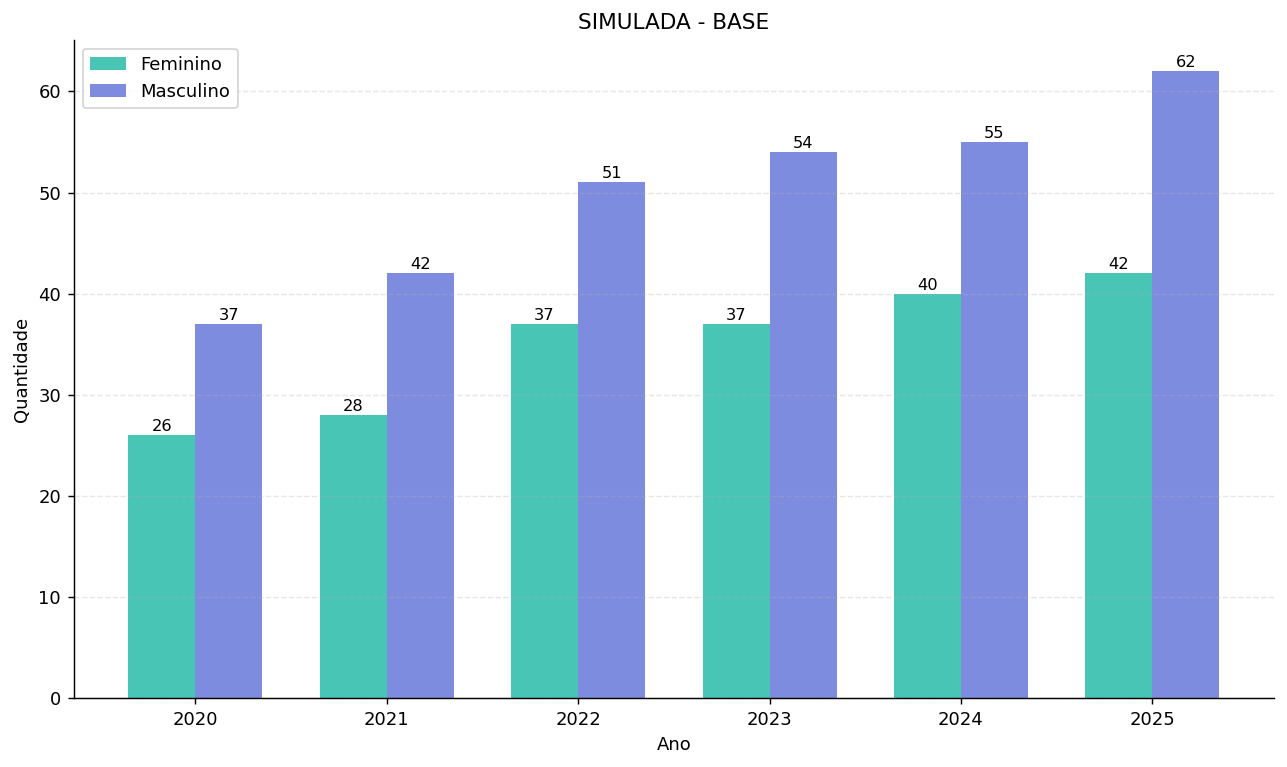

Imagem criada: graficos_gerados\BASE_SIMULADA.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\BASE_SIMULADA.png



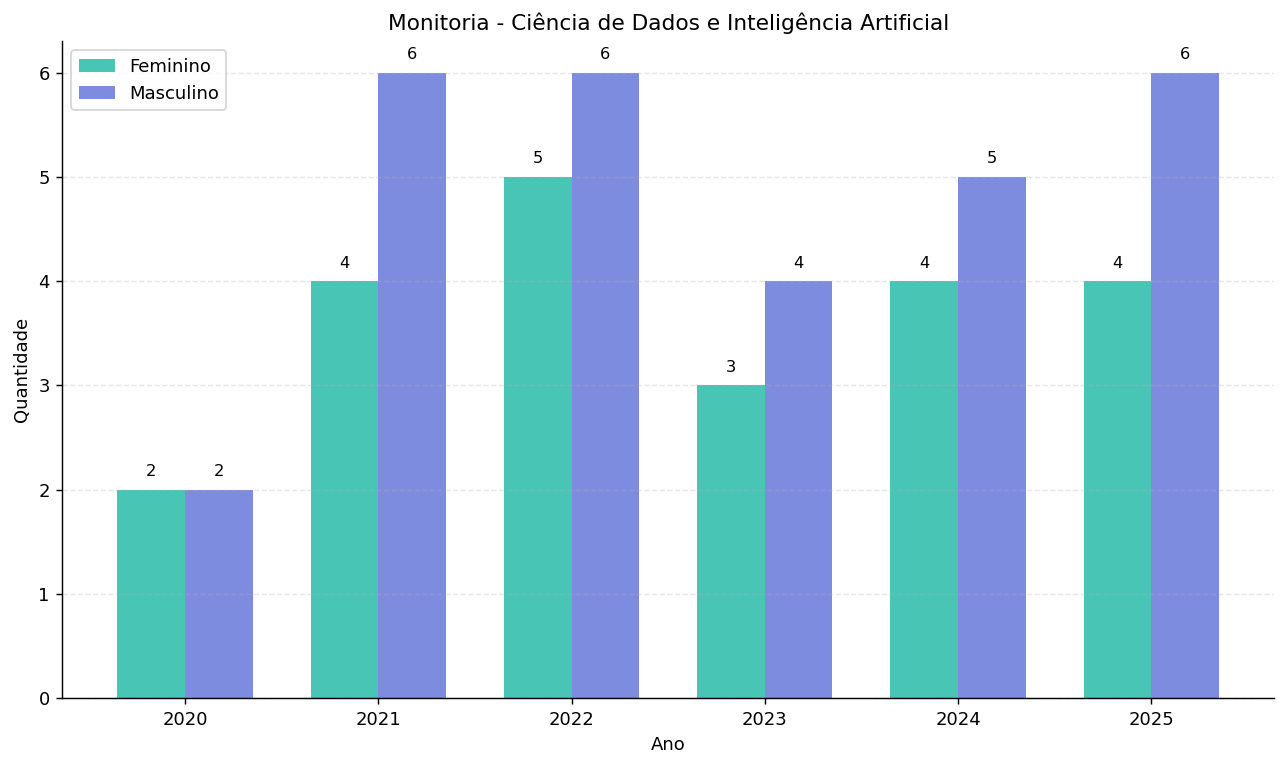

Imagem criada: graficos_gerados\CDIA_MONITORIA.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\CDIA_MONITORIA.png



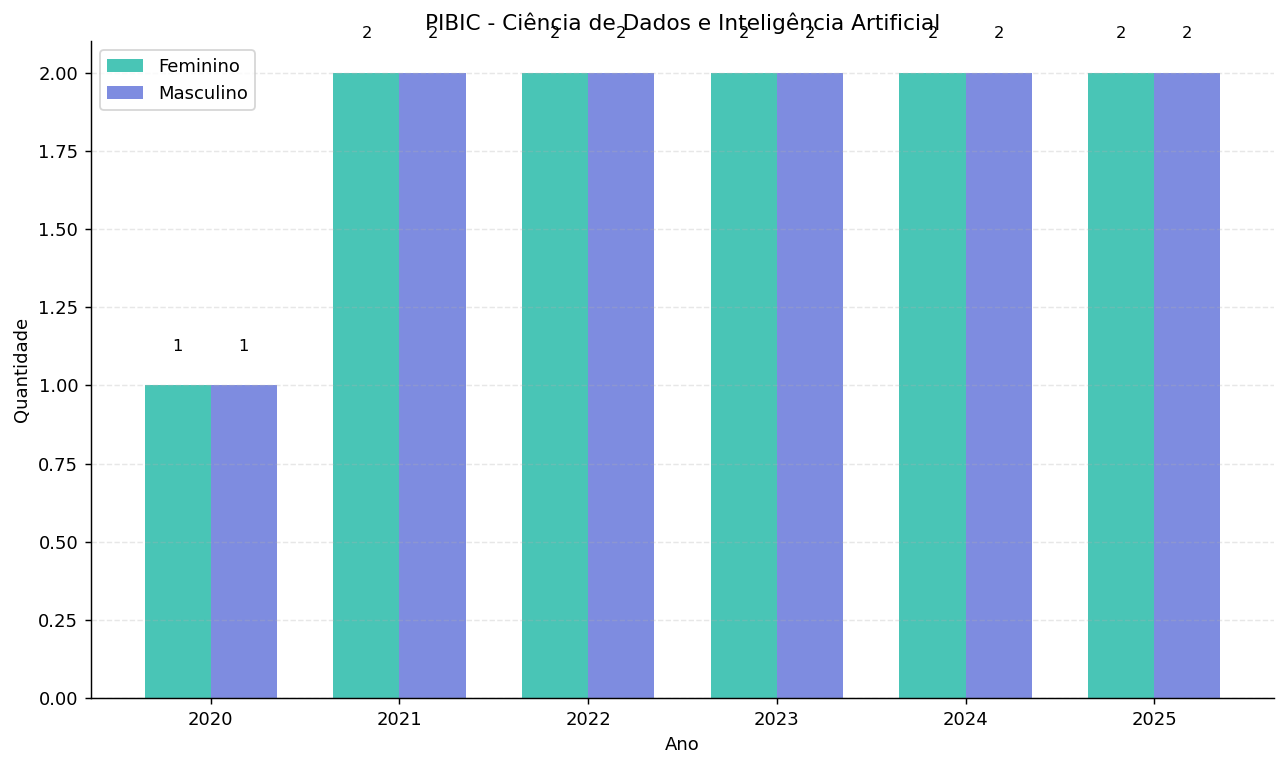

Imagem criada: graficos_gerados\CDIA_PIBIC.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\CDIA_PIBIC.png



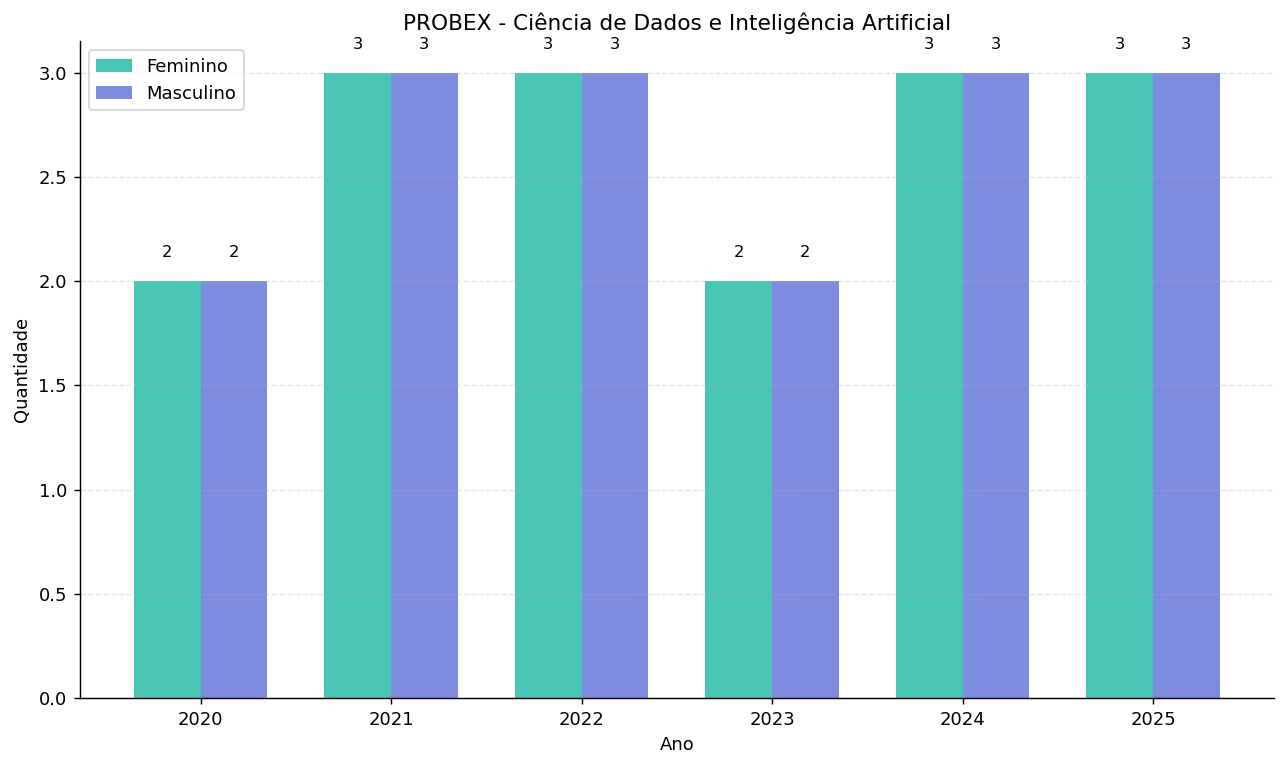

Imagem criada: graficos_gerados\CDIA_PROBEX.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\CDIA_PROBEX.png



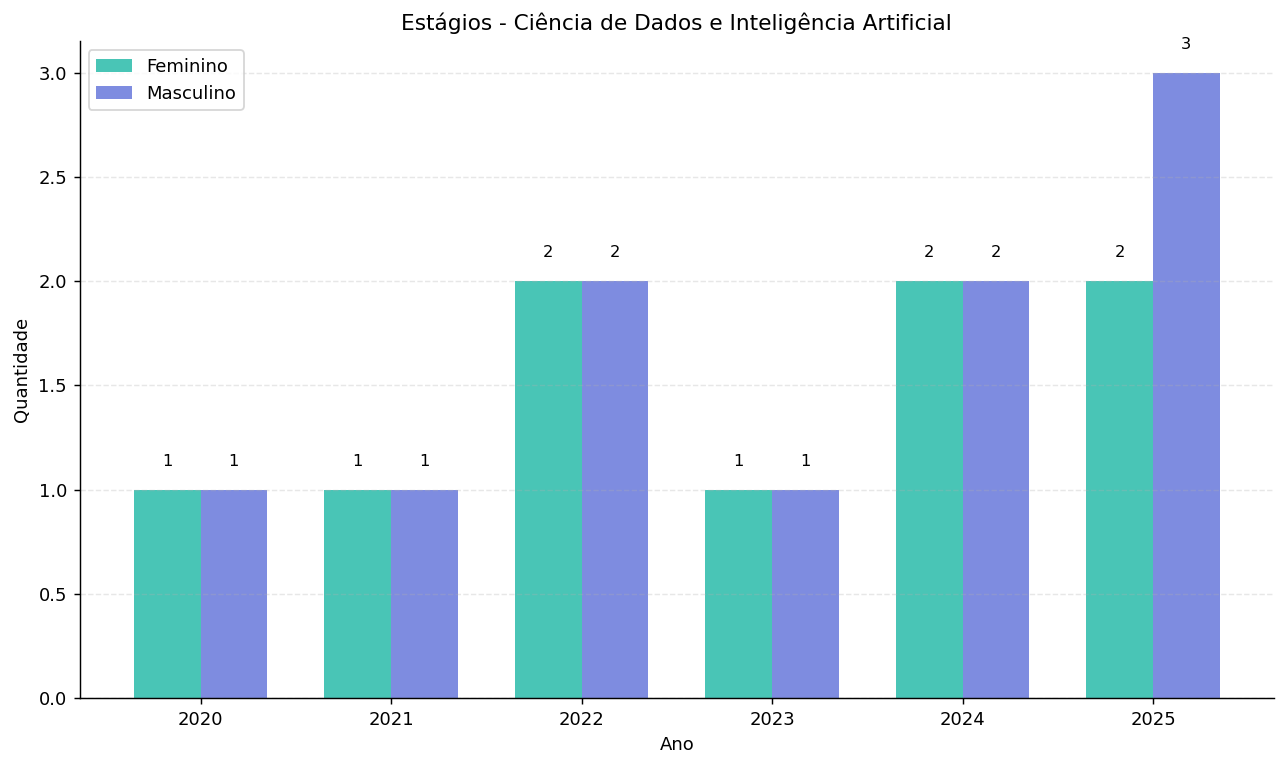

Imagem criada: graficos_gerados\CDIA_ESTAGIOS.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\CDIA_ESTAGIOS.png



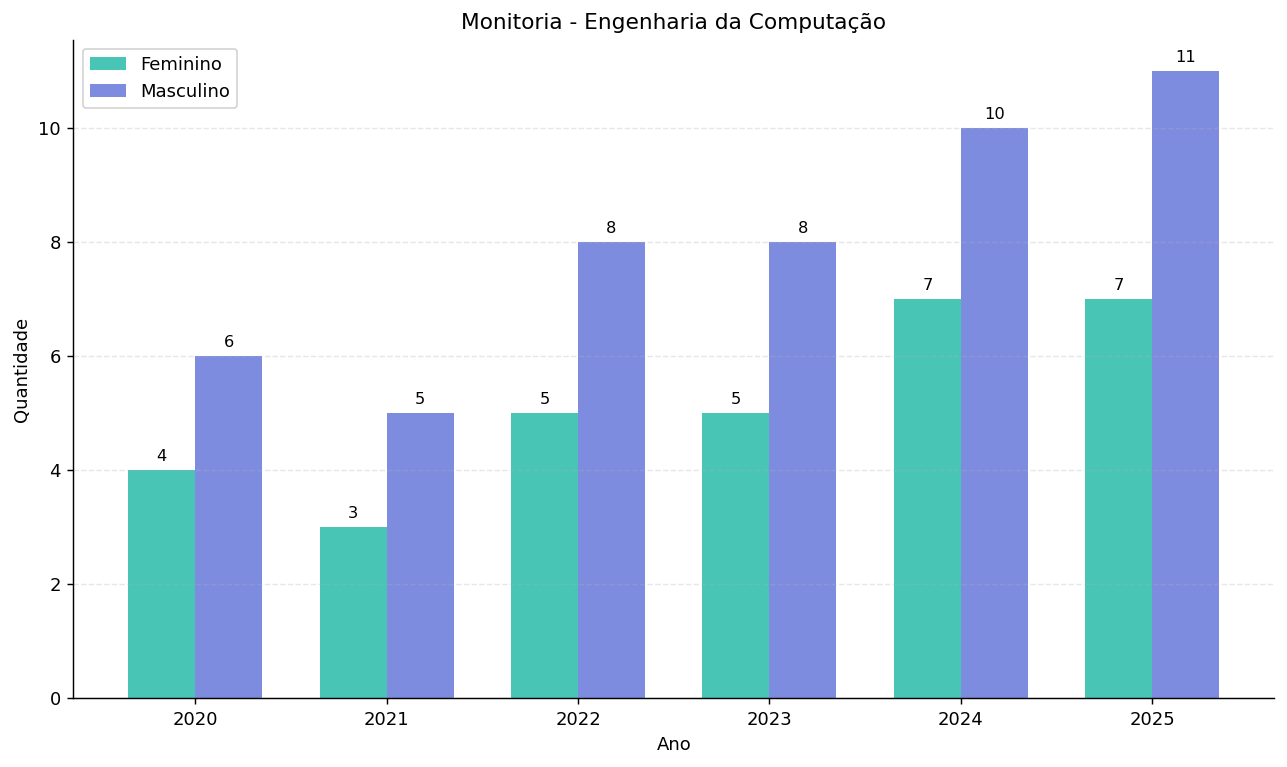

Imagem criada: graficos_gerados\EC_MONITORIA.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\EC_MONITORIA.png



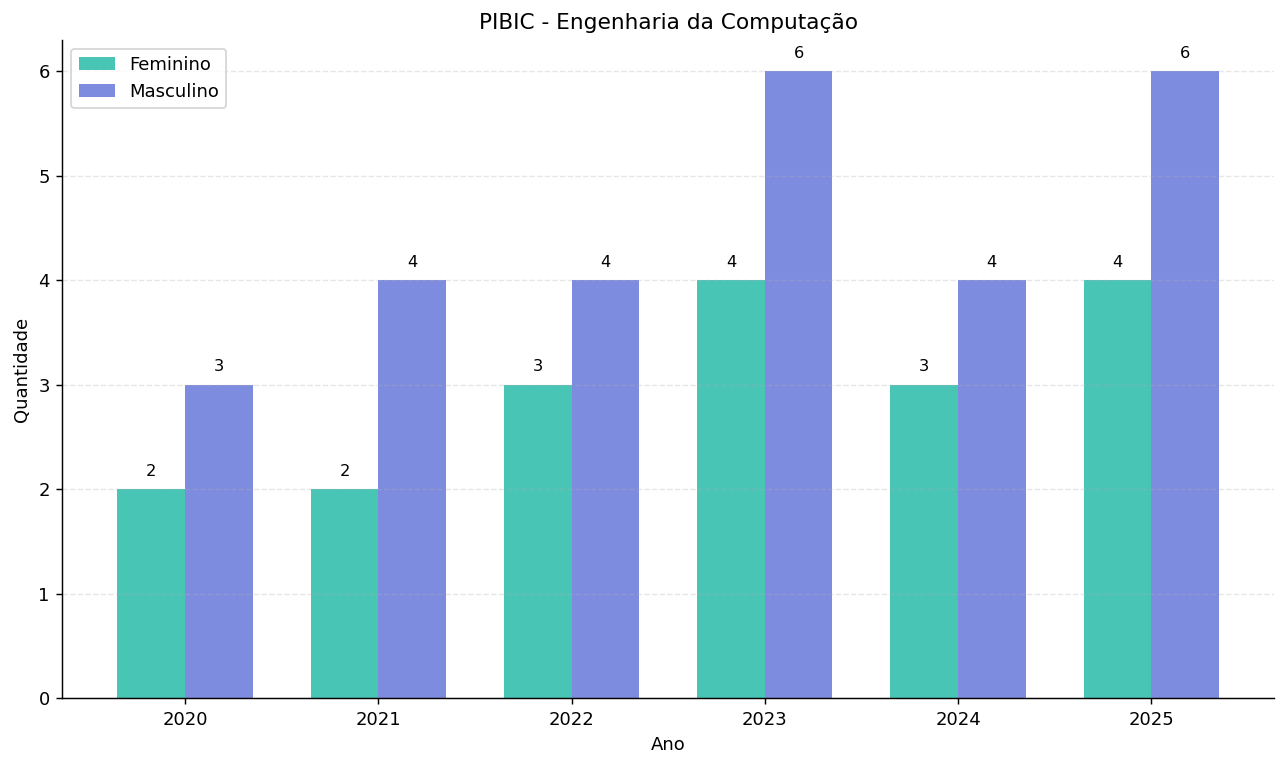

Imagem criada: graficos_gerados\EC_PIBIC.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\EC_PIBIC.png



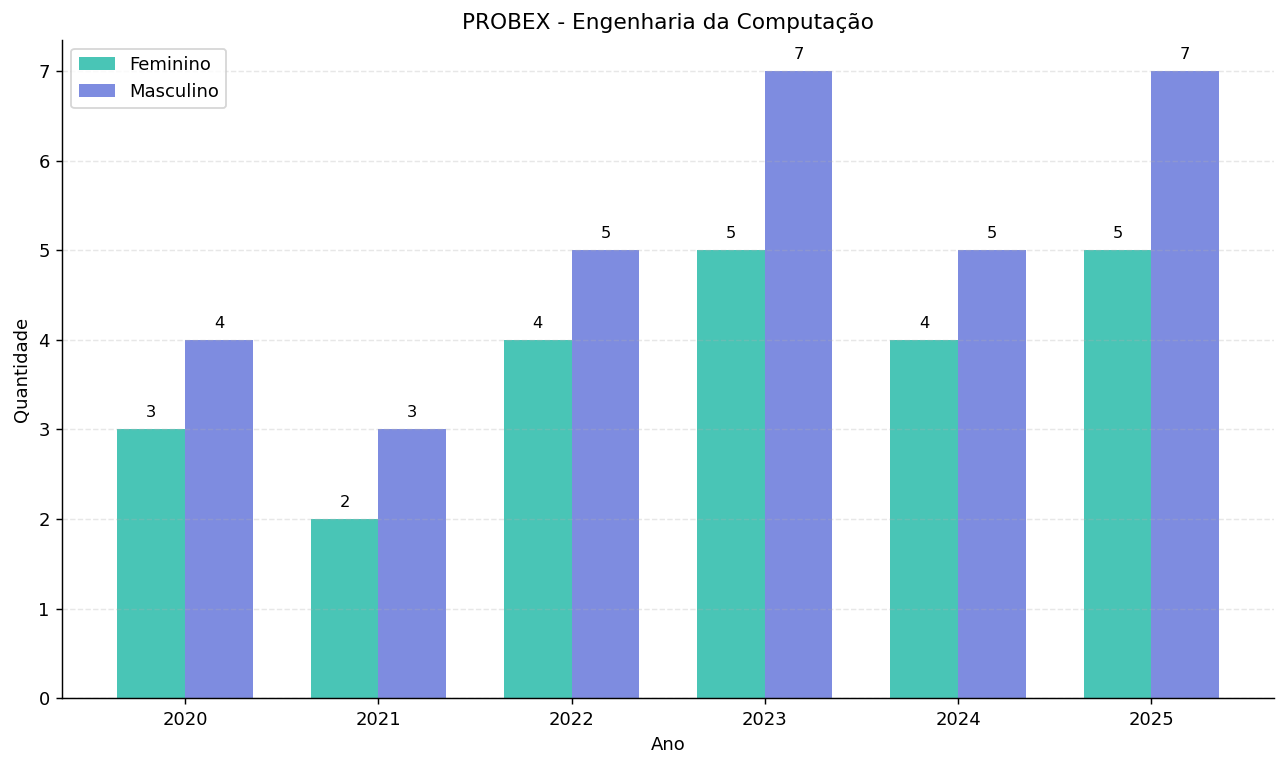

Imagem criada: graficos_gerados\EC_PROBEX.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\EC_PROBEX.png



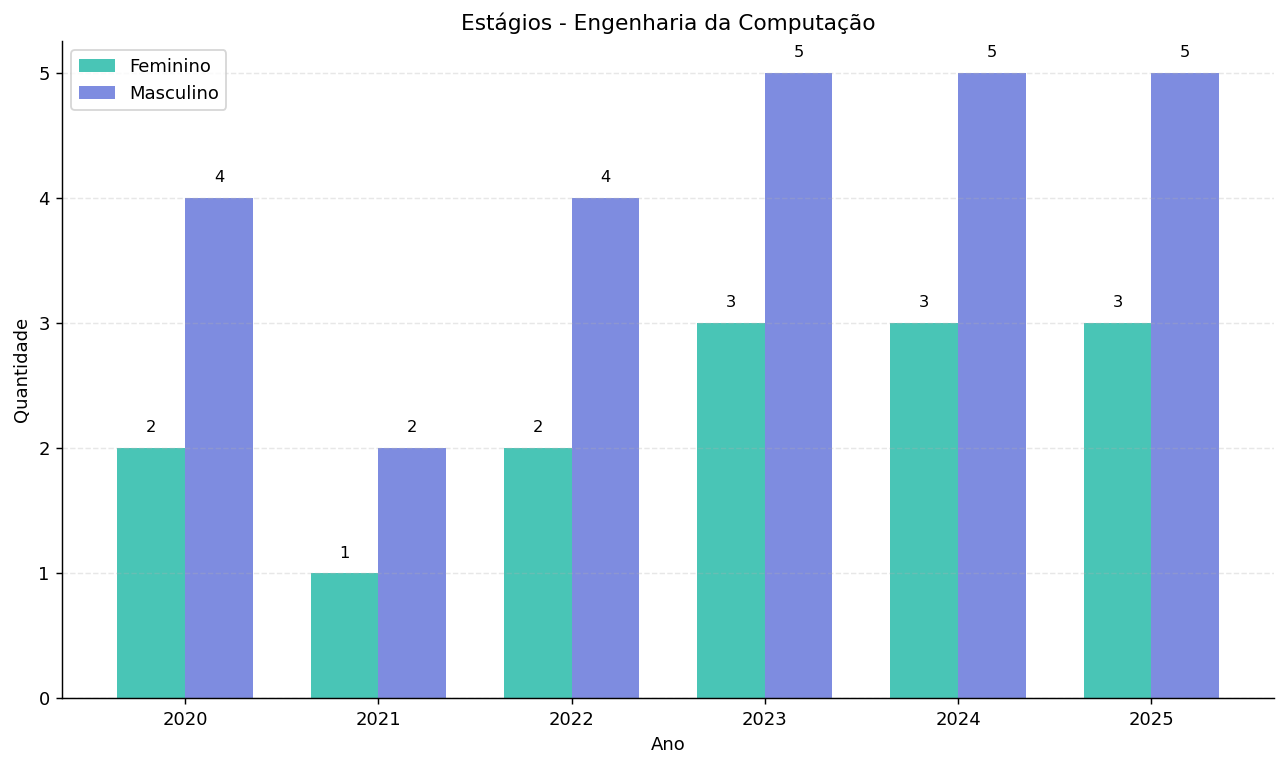

Imagem criada: graficos_gerados\EC_ESTAGIOS.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\EC_ESTAGIOS.png



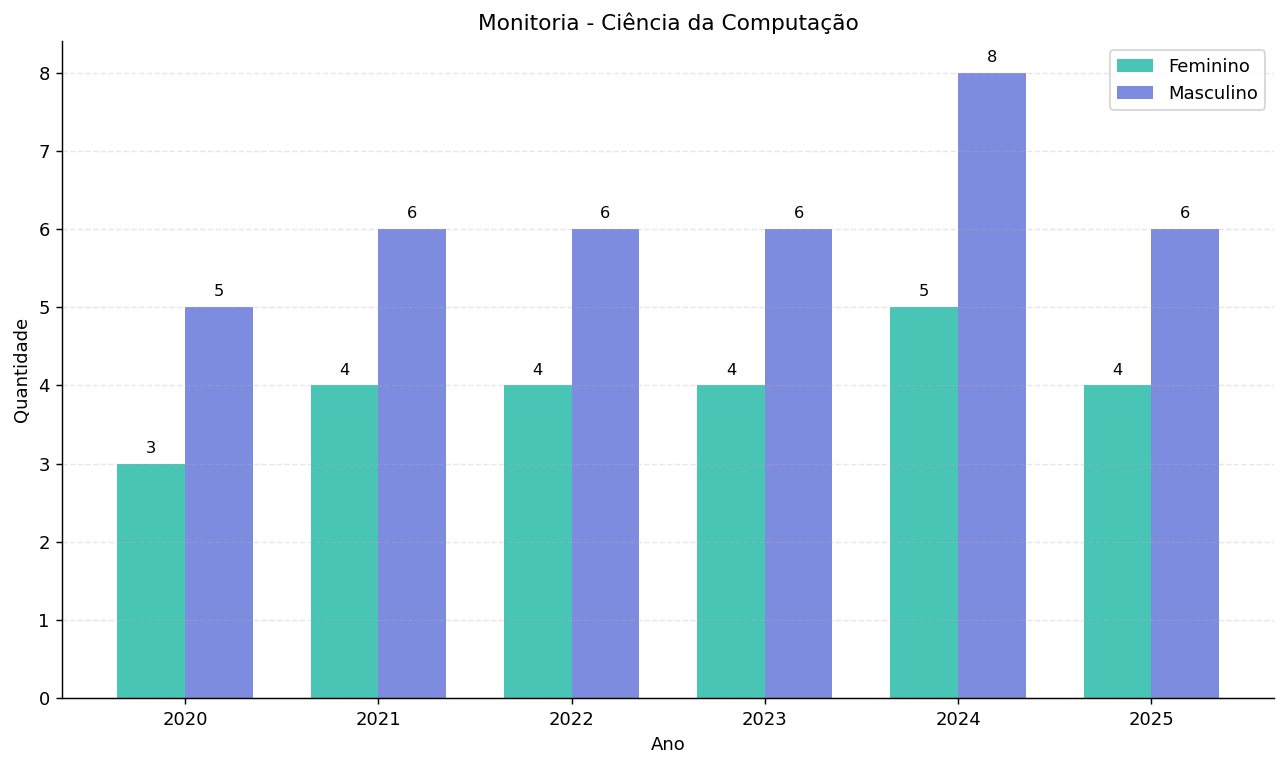

Imagem criada: graficos_gerados\CC_MONITORIA.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\CC_MONITORIA.png



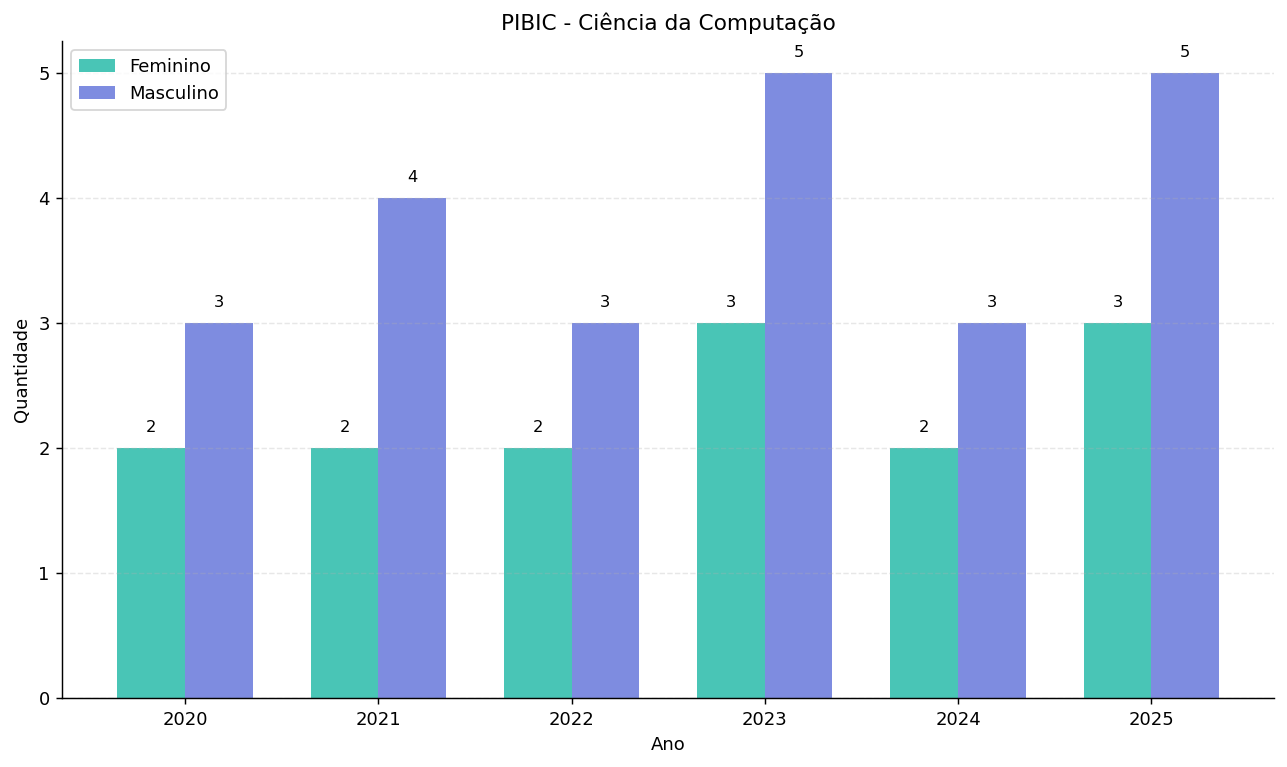

Imagem criada: graficos_gerados\CC_PIBIC.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\CC_PIBIC.png



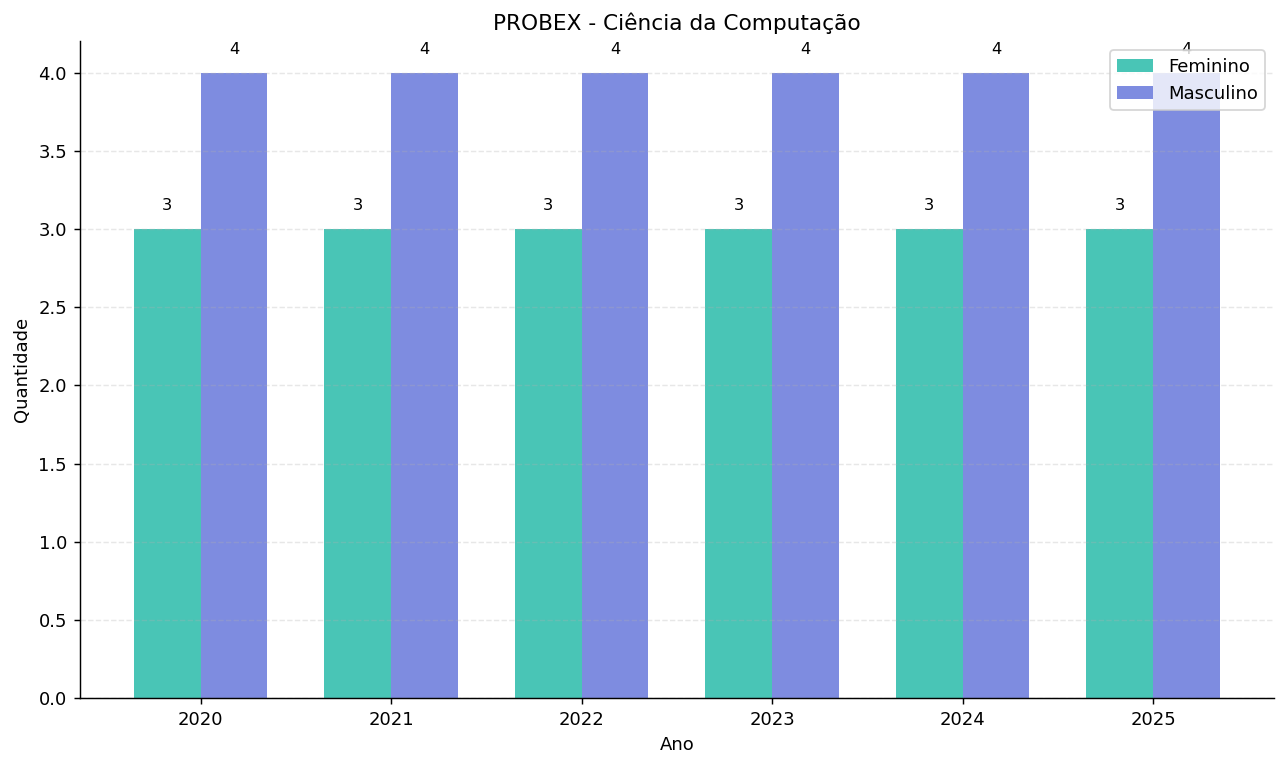

Imagem criada: graficos_gerados\CC_PROBEX.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\CC_PROBEX.png



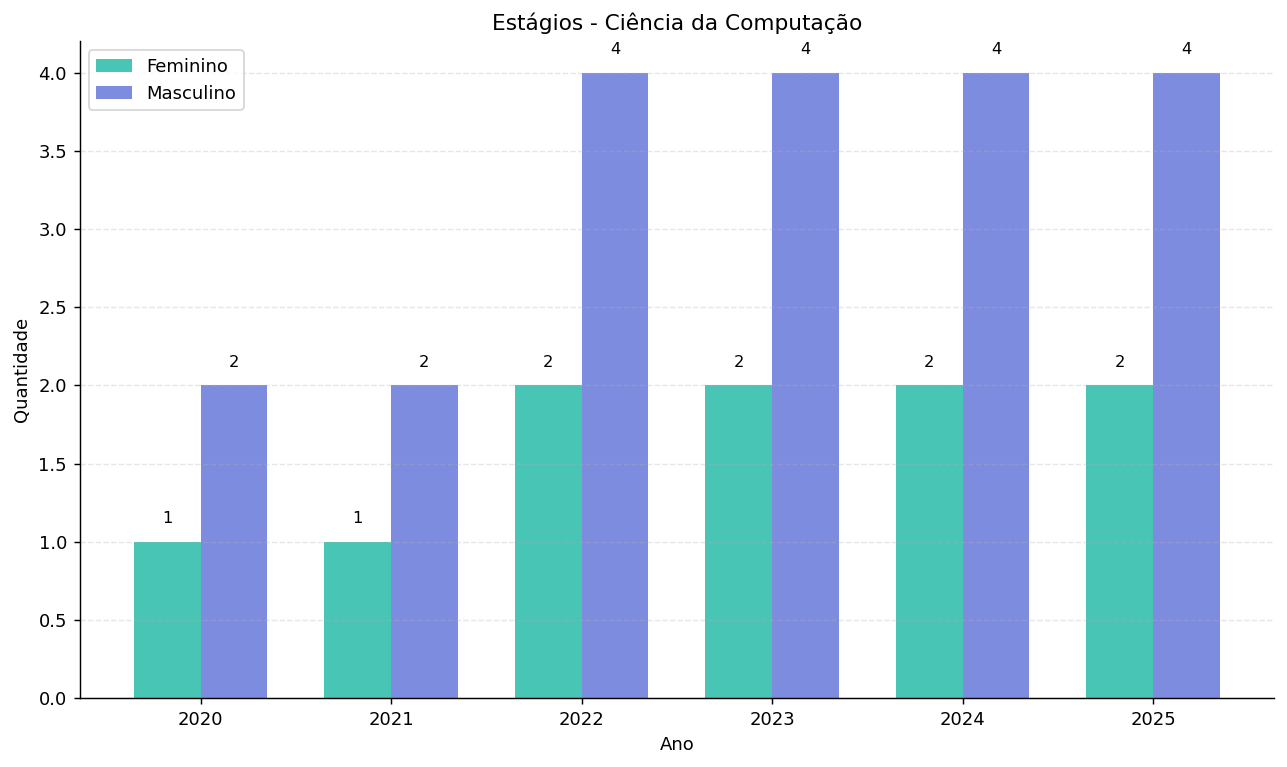

Imagem criada: graficos_gerados\CC_ESTAGIOS.png



<Figure size 832x624 with 0 Axes>

Imagem criada: graficos_gerados\CC_ESTAGIOS.png

Pronto. Todos os gráficos foram salvos na pasta 'graficos_gerados'.


In [27]:
def gerar_grafico(nome_aba, df):
    df_agrupado = df.groupby("Ano")[["Feminino", "Masculino"]].sum().reset_index()

    anos = df_agrupado["Ano"]
    feminino = df_agrupado["Feminino"]
    masculino = df_agrupado["Masculino"]

    x = np.arange(len(anos))
    largura = 0.35

    plt.figure(figsize=(10, 6))
    barras_f = plt.bar(x - largura / 2, feminino, largura, label="Feminino", color="#49C5B6")
    barras_m = plt.bar(x + largura / 2, masculino, largura, label="Masculino", color="#7E8CE0")

    plt.xticks(x, anos)
    plt.ylabel("Quantidade")
    plt.xlabel("Ano")
    plt.title(titulo_aba(nome_aba))
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    for barra in barras_f:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.1,
            f"{int(altura)}",
            ha="center", va="bottom", fontsize=9
        )

    for barra in barras_m:
        altura = barra.get_height()
        plt.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.1,
            f"{int(altura)}",
            ha="center", va="bottom", fontsize=9
        )

    plt.tight_layout()
    caminho = os.path.join(PASTA_SAIDA, f"{nome_aba}.png")
    plt.savefig(caminho, dpi=300, bbox_inches="tight")
    plt.show() # O gráfico agora aparecerá lindo e agrupado!
    plt.close()
    print(f"Imagem criada: {caminho}\n")

    plt.tight_layout()
    caminho = os.path.join(PASTA_SAIDA, f"{nome_aba}.png")
    plt.savefig(caminho, dpi=300, bbox_inches="tight")
    plt.show() # <--- Adicionado para que o gráfico apareça no Jupyter!
    plt.close()
    print(f"Imagem criada: {caminho}\n")

# --- EXECUÇÃO ---
if not os.path.exists(ARQUIVO_EXCEL):
    print(f"Arquivo '{ARQUIVO_EXCEL}' não encontrado.")
else:
    os.makedirs(PASTA_SAIDA, exist_ok=True)
    arquivo = pd.ExcelFile(ARQUIVO_EXCEL)
    abas = arquivo.sheet_names

    print("Gerando gráficos para as abas encontradas...\n")
    for aba in abas:
        try:
            df_bruto = pd.read_excel(ARQUIVO_EXCEL, sheet_name=aba, header=None)
            df = preparar_dataframe(df_bruto)

            if df is None:
                print(f"A aba '{aba}' não possui cabeçalho válido. Pulando...")
                continue

            gerar_grafico(aba, df)

        except Exception as e:
            print(f"Erro na aba '{aba}': {e}")

    print(f"Pronto. Todos os gráficos foram salvos na pasta '{PASTA_SAIDA}'.")

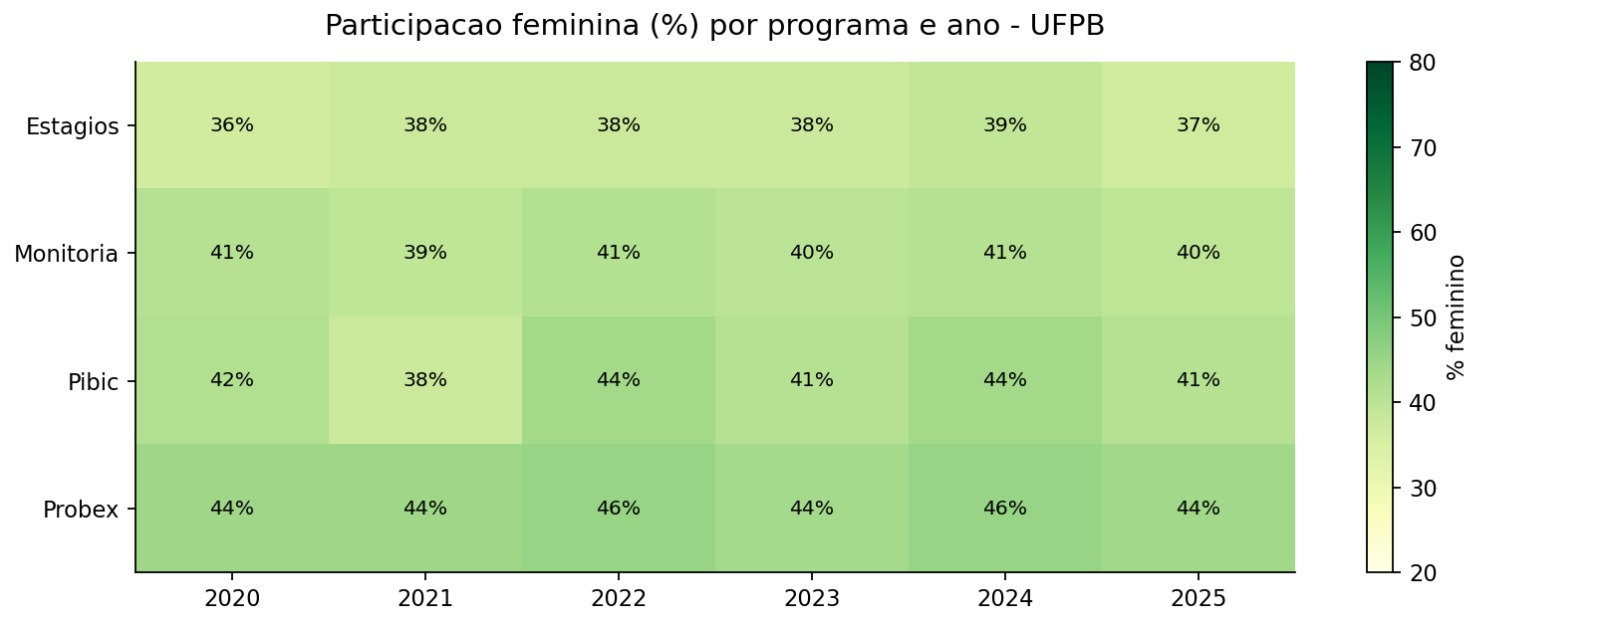

**Respostas**

Através da análise feita, percebe-se que, dentre as modalidades internas do CI, o PROBEX possui a maior participação feminina. No entanto, os gráficos revelam de forma clara que **não há paridade** nos projetos da UFPB. A disparidade entre gêneros é constante e evidente, sendo a participação feminina sempre minoritária em relação à masculina, um padrão que também se reflete na presença em estágios externos.

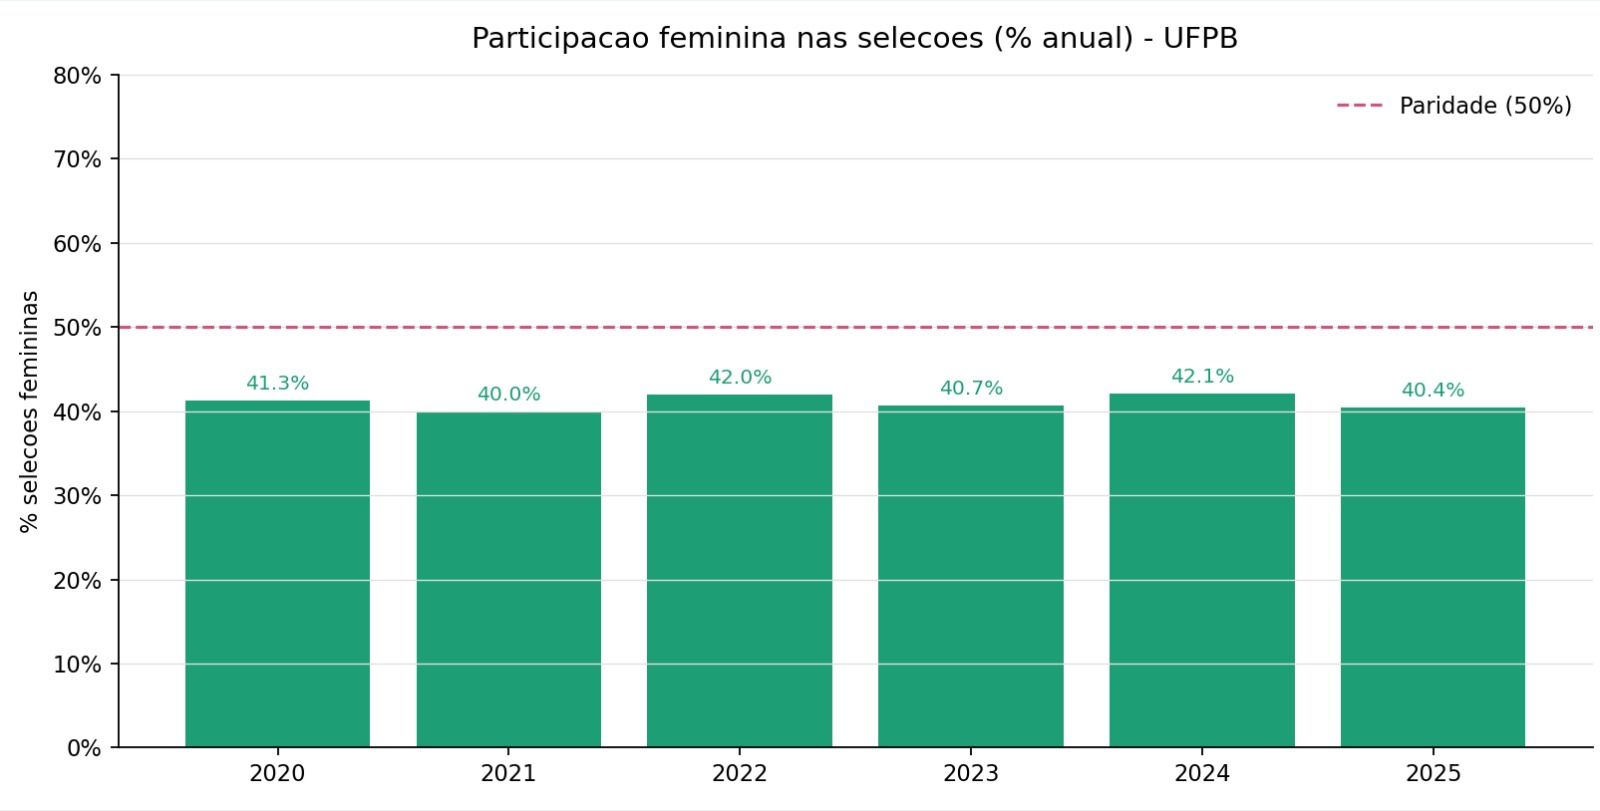

**4. Qual a previsão da participação feminina nos projetos da UFPB para os próximos anos?**

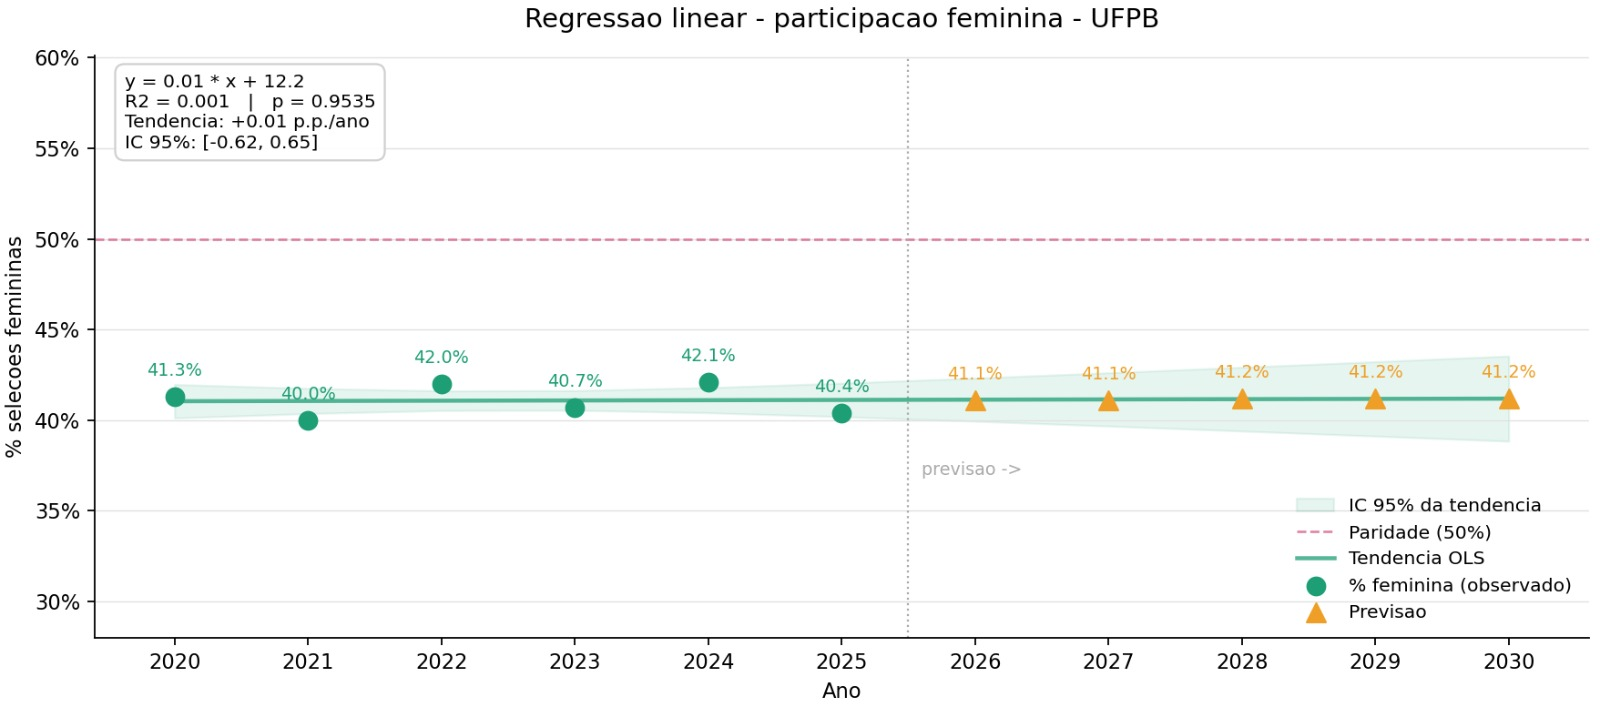

**Resposta**
A partir do cálculo da regressão linear, percebe-se uma reta de tendência praticamente constante. Isso indica que a previsão para os próximos anos é a manutenção da atual taxa de participação feminina, não havendo indícios estatísticos naturais de que a disparidade de gênero nos projetos do CI-UFPB será reduzida a curto prazo sem novas intervenções.

**5. A sub-representação feminina é um fenômeno acadêmico, profissional ou ambos? Comparação da participação percentual entre CI-UFPB e Mercado de Trabalho.**

C:\Users\redca\AppData\Local\Temp\ipykernel_4760\2701186979.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percs_anuais_mercado = df_mercado.groupby(col_ano).apply(


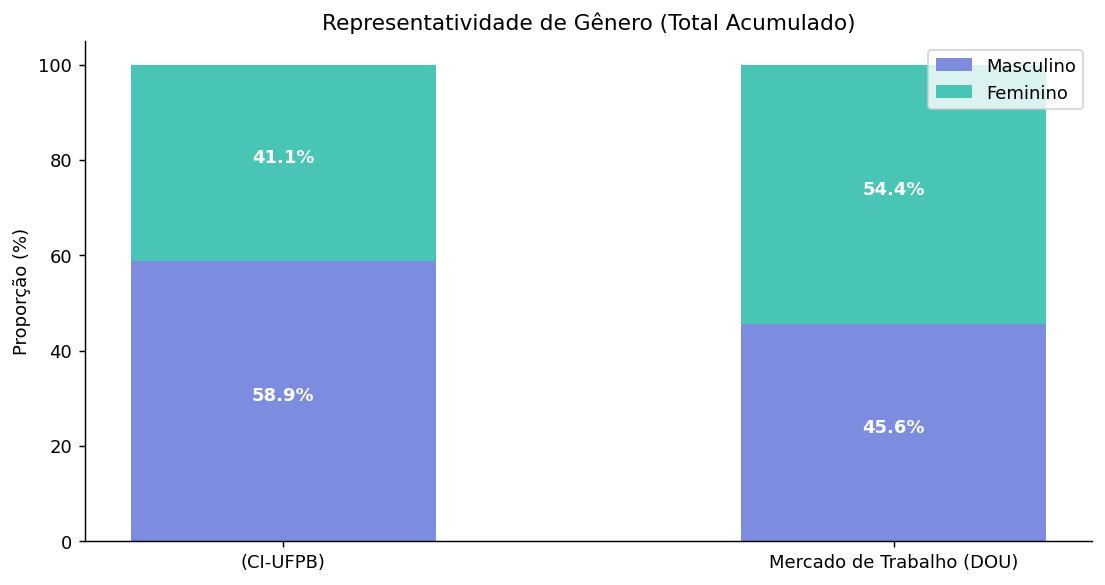

C:\Users\redca\AppData\Local\Temp\ipykernel_4760\2701186979.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([percs_anuais_ci, percs_anuais_mercado], labels=['CI-UFPB', 'Mercado (DOU)'])


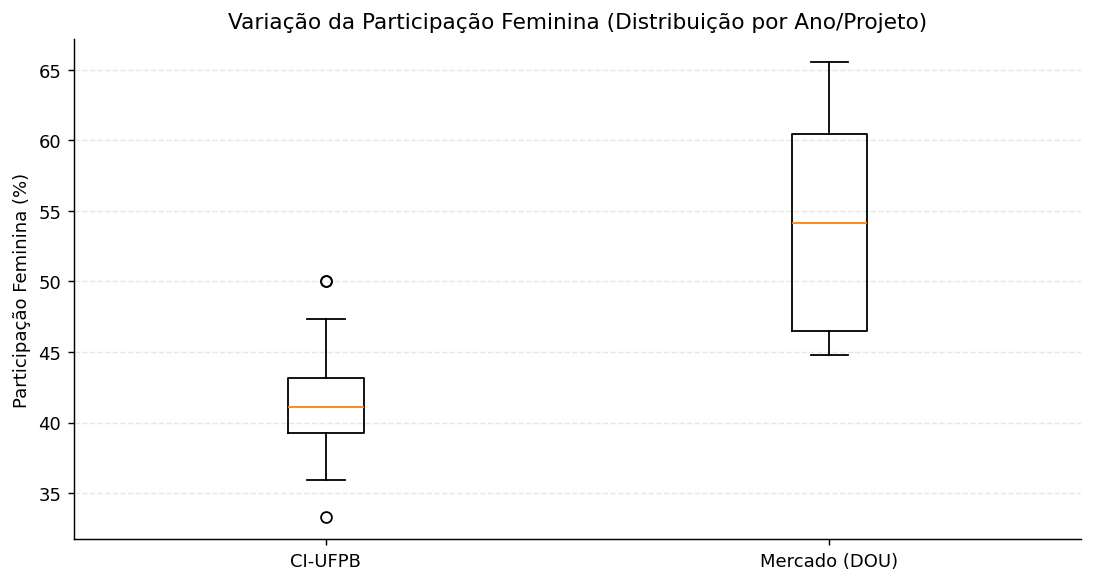

C:\Users\redca\AppData\Local\Temp\ipykernel_4760\2701186979.py:76: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  evolucao_mercado = df_mercado.groupby(col_ano).apply(


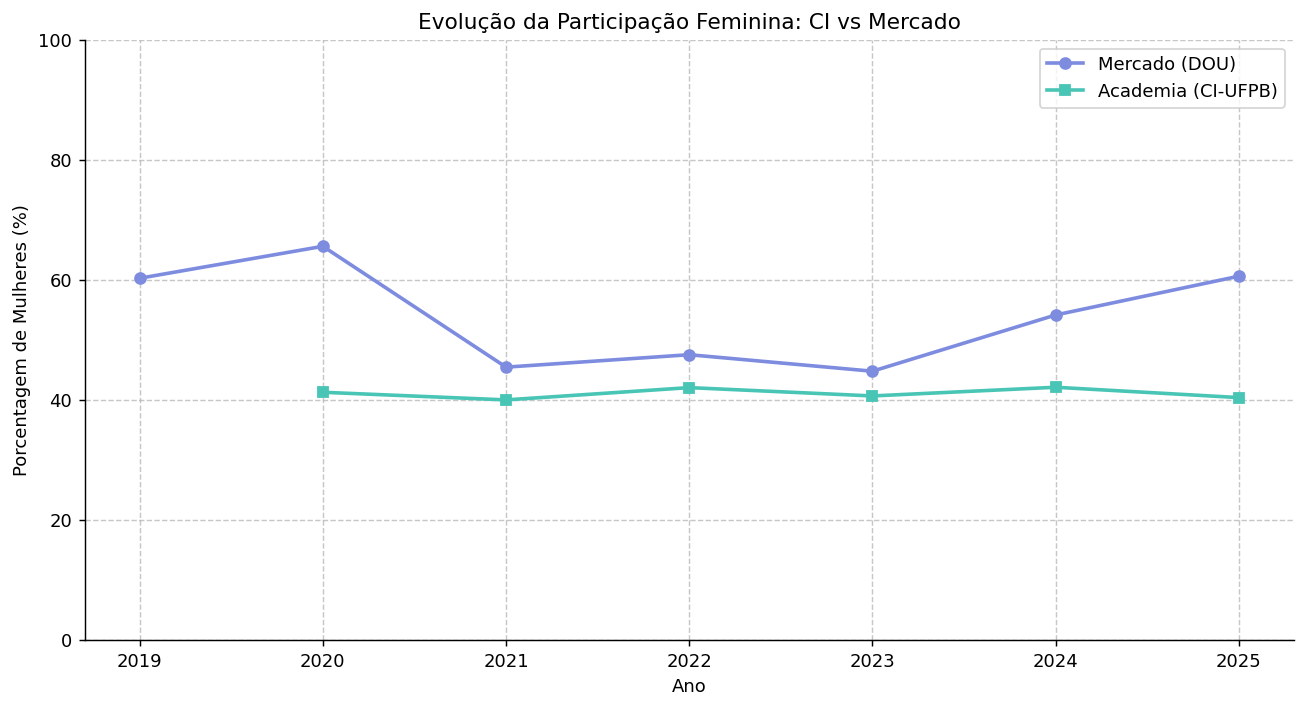

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# CÁLCULOS DO CI
total_f_ci, total_m_ci = 0, 0
percs_anuais_ci = []

arquivo_excel = pd.ExcelFile(ARQUIVO_EXCEL)
for aba in arquivo_excel.sheet_names:
    df_aba = preparar_dataframe(pd.read_excel(ARQUIVO_EXCEL, sheet_name=aba, header=None))
    if df_aba is not None:
        f = df_aba['Feminino'].sum()
        m = df_aba['Masculino'].sum()
        total_f_ci += f
        total_m_ci += m
        if (f + m) > 0:
            percs_anuais_ci.append((f / (f + m)) * 100)

#CÁLCULOS DO MERCADO (DOU) 
df_mercado = pd.read_csv("nomeacoes_limpo.csv")
df_mercado["Data"] = pd.to_datetime(df_mercado["Data"], format="%d-%m-%Y")
df_mercado["Ano"] = df_mercado["Data"].dt.year
df_mercado = df_mercado[df_mercado["Ano"] < 2026].copy()

df_mercado.columns = [str(col).strip().lower() for col in df_mercado.columns]
col_gen = next((c for c in ['genero', 'gênero', 'sexo'] if c in df_mercado.columns), None)

if col_gen:
    contagem = df_mercado[col_gen].str.strip().str.lower().value_counts()
    total_f_mercado = contagem.get('feminino', 0)
    total_m_mercado = contagem.get('masculino', 0)
    
    col_ano = next((c for c in ['ano', 'Ano'] if c in df_mercado.columns), 'ano')
    percs_anuais_mercado = df_mercado.groupby(col_ano).apply(
        lambda x: (x[col_gen].str.contains('feminino', case=False).sum() / len(x)) * 100
    ).tolist()
else:
    raise KeyError("Coluna de gênero não encontrada no dado do Mercado.")

perc_ci = (total_f_ci / (total_f_ci + total_m_ci)) * 100
perc_mercado = (total_f_mercado / (total_f_mercado + total_m_mercado)) * 100

#GRÁFICO 1: BARRAS EMPILHADAS 100%
plt.figure(figsize=(10, 5))
labels = ['(CI-UFPB)', 'Mercado de Trabalho (DOU)']
mulheres = [perc_ci, perc_mercado]
homens = [100 - perc_ci, 100 - perc_mercado]

plt.bar(labels, homens, label='Masculino', color='#7E8CE0', width=0.5)
plt.bar(labels, mulheres, bottom=homens, label='Feminino', color='#49C5B6', width=0.5)

plt.ylabel('Proporção (%)')
plt.title('Representatividade de Gênero (Total Acumulado)')
plt.legend(loc='upper right')

for i in range(len(labels)):
    plt.text(i, homens[i]/2, f'{homens[i]:.1f}%', ha='center', color='white', fontweight='bold')
    plt.text(i, homens[i] + mulheres[i]/2, f'{mulheres[i]:.1f}%', ha='center', color='white', fontweight='bold')

plt.savefig(os.path.join(PASTA_SAIDA, "p5_barras_empilhadas.png"), dpi=300, bbox_inches="tight")
plt.show()

#GRÁFICO 2: BOXPLOT (DISPERSÃO E VARIAÇÃO ANUAL)
plt.figure(figsize=(10, 5))
plt.boxplot([percs_anuais_ci, percs_anuais_mercado], labels=['CI-UFPB', 'Mercado (DOU)'])

plt.ylabel('Participação Feminina (%)')
plt.title('Variação da Participação Feminina (Distribuição por Ano/Projeto)')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.savefig(os.path.join(PASTA_SAIDA, "p5_boxplot_variacao.png"), dpi=300, bbox_inches="tight")
plt.show() 

#GRÁFICO 3: EVOLUÇÃO TEMPORAL (CI vs MERCADO POR ANO)
evolucao_mercado = df_mercado.groupby(col_ano).apply(
    lambda x: (x[col_gen].str.contains('feminino', case=False).sum() / len(x)) * 100
)

dados_ci_por_ano = {}
for aba in arquivo_excel.sheet_names:
    df_temp = preparar_dataframe(pd.read_excel(ARQUIVO_EXCEL, sheet_name=aba, header=None))
    if df_temp is not None:
        for index, row in df_temp.iterrows():
            ano = row['Ano']
            if ano not in dados_ci_por_ano:
                dados_ci_por_ano[ano] = {'f': 0, 'total': 0}
            dados_ci_por_ano[ano]['f'] += row['Feminino']
            dados_ci_por_ano[ano]['total'] += (row['Feminino'] + row['Masculino'])

anos_ordenados = sorted(dados_ci_por_ano.keys())
evolucao_ci = pd.Series({ano: (dados_ci_por_ano[ano]['f'] / dados_ci_por_ano[ano]['total'] * 100) 
                         for ano in anos_ordenados if dados_ci_por_ano[ano]['total'] > 0})

plt.figure(figsize=(12, 6))

plt.plot(evolucao_mercado.index, evolucao_mercado.values, marker='o', label='Mercado (DOU)', color='#7E8CE0', linewidth=2)
plt.plot(evolucao_ci.index, evolucao_ci.values, marker='s', label='Academia (CI-UFPB)', color='#49C5B6', linewidth=2)

plt.title('Evolução da Participação Feminina: CI vs Mercado')
plt.xlabel('Ano')
plt.ylabel('Porcentagem de Mulheres (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.ylim(0, 100)

plt.savefig(os.path.join(PASTA_SAIDA, "p5_evolucao_temporal.png"), dpi=300, bbox_inches="tight")
plt.show()

**Resposta**
O que os dados “falam”: Cruzando as informações do Centro de Informática com os dados de contratações do Diário Oficial, a resposta curta é: infelizmente, de ambos. Mas cada lugar tem o seu jeito de mostrar esse problema.

Não dá para culpar apenas um lado. A sub-representação é um problema real que começa na universidade e continua na carreira profissional. Por isso, projetos que incentivam estudantes mulheres não são apenas "legais", eles são necessários para tentar "puxar" essas linhas e caixinhas para cima nos próximos anos!

### Conclusão

Para resumir, nossa análise revelou dois cenários que precisam de atenção. Por um lado, **os dados do mercado de trabalho (Diário Oficial da União) variam bastante**. Embora a regressão linear aponte para uma tendência de queda, o volume de convocações oscila tanto que fica muito difícil prever alguma estabilidade a curto prazo. Por outro lado, olhando para dentro da UFPB, os números mostram uma **disparidade de gênero persistente na execução dos projetos do CI**. A participação feminina continua sendo minoria e, segundo a tendência estatística que calculamos, isso deve se manter constante. Ou seja: enquanto o mercado de trabalho é marcado por altos e baixos imprevisíveis, a falta de representatividade feminina dentro da universidade é uma barreira estrutural muito clara, que não vai diminuir sozinha.

**Limitações:** Encontramos algumas barreiras durante o estudo. A principal foi a grande variação e dispersão nos dados do Diário Oficial, o que deixou o coeficiente do nosso modelo de regressão bem baixo e dificultou previsões de longo prazo mais exatas.

**Trabalhos Futuros e Melhorias:** Como próximos passos, seria muito interessante ampliar a base de dados, incluindo outras universidades e também analisando contratações públicas estaduais e municipais, para ver se esse mesmo padrão de desigualdade se repete em outros escopos. Outra melhoria valiosa seria cruzar esses dados de mercado com a participação em iniciativas focadas na permanência de mulheres em STEM. Avaliar separadamente o histórico em projetos de extensão, como o Meninas na Ciência da Computação, ou a vivência em grupos estudantis, como o WIE UFPB, nos permitiria medir com estatística real o impacto dessas diferentes ações na taxa de sucesso e na empregabilidade das estudantes a longo prazo.
